# Marketplace Analysis

## Case Background

**Research Objective:**

To analyze marketplace metrics in order to identify potential issues, early warning signals and actionable insights.

**Analysis Stages**

**Stage 1:** Initial data exploration and data collection

**Stage 2:** Key metrics overview

**Stage 3:** Monetization and unit economics analysis

**Stage 4:** Segmentation, insight discovery, and hypothesis generation

**Stage 5:** Experiment setup and results evaluation

## Data Description

### Users Table

| Field              | Description                                    |
|-------------------|------------------------------------------------|
| `user_id`         | Unique user indetifier.         |
| `registration_date` | User registration date.                |
| `age`             | User age.                          |
| `gender`          | Gender.                                |
| `region`          | Region.                                        |
| `acq_channel`     | Acquisition channel.                             |
| `buyer_segment`   | Buyer segment.                            |
| `cohort_week`     | Acquisition cohort (week).|
| `cohort_month`    | Acquisition cohort (month). |

---

### Events Table

| Field          | Description                                                                 |
|---------------|--------------------------------------------------------------------------|
| `event_id`    | Unique event identifier.                                        |
| `user_id`     | User identifier.                                              |
| `event_date`  | Event date.                                                            |
| `event_type`  | Event type.   |
| `os`          | Operating system.               |
| `device`      | Device type.                                |
| `product_name`|Product name related to the event (if applicable).      |
| `event_week`  | Event week.                                          |
| `event_month` | Event month .                                           |

---

### Orders Table

| Field         | Description                                                                 |
|---------------|--------------------------------------------------------------------------|
| `order_id`    | Unique order identifier.                                         |
| `user_id`     | Identifier of the user who placed the order |
| `order_date`  | Order date and time.                                          |
| `product_name`| Product name.                                                     |
| `quantity`    | Number of items in the order.                                       |
| `unit_price`  | Price per unit.                                             |
| `total_price` | Total order value.                                                   |
| `category_name` | Product category name.                                         |
| `order_week`  | Order week.                                           |
| `order_month` | Order month.                                            |


### Campaign_costs Table

| Field         | Desciption                                                                 |
|--------------|--------------------------------------------------------------------------|
| `acq_channel`| Acquisition channel.  |
| `spend_month`| Month when the market budget was spent (when users were acquired)                      |
| `budget`     | Marketing budget spent on the given channel during the specified month.                           |



### Event Description

| Event             | Desciption                                                                                  |
|---------------------|-------------------------------------------------------------------------------------------|
| `page_view`         | User opens any page of the website or mobile application.                                |
| `product_view`      | User views a specific product page.                                                     |
| `product_click`     | User clicks on a product (e.g., from a product list or banner).                              |
| `add_to_cart`       | Procut is added to the shopping cart.                                                              |
| `remove_from_cart`  | Product is removed from the shopping cart.                                                               |
| `search`            | User performs a search on the website or application.                                                |
| `filter_apply`      |User applies a filter (e.g., by price, brand, or category).                                |
| `checkout_start`    | User starts the checkout process (proceeds to cart checkout).                                  |
| `checkout_complete` | Checkout process is completed (does not guarantee a purchase; purchase depends on payment confirmation).                                          |
| `user_login`        | User logs into their account.                                           |
| `user_logout`       | User logs out of their account.                                                           |
| `wishlist_add`      | Product is added to the wishlist.                                          |
| `category_view`     | User views a product category page.                                                      |
| `banner_click`      | User clicks on a promotional banner on the website or application.                                     |
| `promo_view`        | User views a promotion or special offer.                                        |


#### Revenue Definition

Markeplace revenue equals 5 % of total_price.

##  1. Initial data exploration and data collection

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import numpy as np
from matplotlib.ticker import FuncFormatter
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats
import scipy.stats as stats
from scipy.stats import ttest_ind
import matplotlib.dates as mdates
import datetime as dt

In [3]:
orders = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_orders.csv', parse_dates=['order_date', 'order_week','order_month'])
campaigns = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_campaign_costs.csv', parse_dates=['spend_month'])
users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_users.csv', parse_dates=['registration_date', 'cohort_week', 'cohort_month'])
events = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_events.csv', parse_dates=['event_date', 'event_week', 'event_month'])

**Orders Data**

In [4]:
print(orders.info())
print('\nMissing values:\n', orders.isna().sum())
print('\nUnique values:\n', orders.nunique())
print('\nSample rows:\n', orders.sample(3))
print('\nDuplicates count:', orders.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31357 entries, 0 to 31356
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       31357 non-null  int64         
 1   user_id        31357 non-null  int64         
 2   order_date     31357 non-null  datetime64[ns]
 3   product_name   31357 non-null  object        
 4   quantity       31357 non-null  int64         
 5   unit_price     31357 non-null  float64       
 6   total_price    31357 non-null  float64       
 7   category_name  31357 non-null  object        
 8   order_week     31357 non-null  datetime64[ns]
 9   order_month    31357 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.4+ MB
None

Missing values:
 order_id         0
user_id          0
order_date       0
product_name     0
quantity         0
unit_price       0
total_price      0
category_name    0
order_week       0
orde

**Intermediate conclusion. Orders Data**

The orders table contains 10 columns each with the same number of records - 31,357 rows. There are no missing values in the dataset.

Data types:

- order_id, user_id, quantity - int64
- order_date, order_week, order_month- datetime64[ns]
- product_name, category_name - object
- unit_price, total_price - float64.

All fields are stored using appropriate type. The table includes 200 unique product names across 25 product categories. No explicit duplicates were detected.

In [5]:
orders['category_name'].value_counts()

Продукты питания                   4027
Детская одежда                     1421
Зоотовары                          1396
Книги и канцтовары                 1316
Аксессуары для гаджетов            1255
Обувь мужская                      1253
Одежда для спорта                  1248
Товары для кухни                   1237
Обувь женская                      1211
Женская одежда                     1191
Сумки и аксессуары                 1180
Средства для ухода                 1172
Товары для новорожденных           1161
Детские игрушки                    1131
Косметика и парфюмерия             1057
Декор и освещение                  1053
Автотовары                         1043
Бытовая техника                    1030
Украшения и часы                   1024
Мужская одежда                     1022
Спортивный инвентарь               1000
Инструменты и садовый инвентарь    1000
Медицинские товары                  980
Мебель для дома                     979
Товары для туризма                  970


In [6]:
orders['product_name'].value_counts()

Гречка ядрица           536
Рис длиннозерный        521
Масло подсолнечное      510
Макароны                508
Чай черный              501
                       ... 
Штанга олимпийская      109
Кольцо с бриллиантом    106
Запонки классические    106
Чехлы на сиденья        105
Кровать двуспальная     100
Name: product_name, Length: 200, dtype: int64

In [9]:
orders['unit_price'].describe()

count    31357.000000
mean      6986.909334
std       8170.131920
min        339.000000
25%       2155.370000
50%       4406.630000
75%       9395.950000
max      63932.380000
Name: unit_price, dtype: float64

**Intermediate conclusion. Unit prices**

Unit prices show high variability, ranging from 339 RUB to 63,932 RUB per item. The median price is 4,406 RUB, while the mean price is higher at 6,986 RUB, with a standard deviation of 8,170 RUB.

The price distribution is right-skewed, indicating the presence of high-priced items that pull the average upward. The majority of products are concentrated within the 2,000 RUB – 7,000 RUB price range.

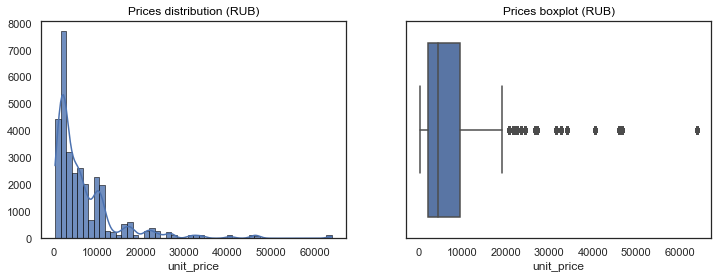

In [10]:
# Check prices distribution

plt.figure(figsize=(12,4))
sns.set_theme(style="white")

plt.subplot(1,2,1)
sns.histplot(orders['unit_price'].dropna(), bins=50, kde=True, edgecolor='black', alpha=0.8)
plt.title('Prices distribution (RUB)', color='black')
plt.ylabel('')

plt.subplot(1,2,2)
sns.boxplot(x=orders['unit_price'].dropna())
plt.title('Prices boxplot (RUB)', color='black')

plt.show()

**Intermediate Conclusion. Price distribution check**

Most products are priced below 10,000 RUB, while high-priced items are present but rare. These expensive items are the main drivers of the high standard deviation.

The interquartile range is relatively narrow and concentrated in the lower price segment, indicating that the core market is composed of lower-priced products.

**Campaigns Data**

In [11]:
print(campaigns.info())
print('\nMissing values:\n', campaigns.isna().sum())
print('\nUnique values:\n', campaigns.nunique())
print('\nSample rows:\n', campaigns.sample(3))
print('\nDuplicates count:', campaigns.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Unnamed: 0   88 non-null     int64         
 1   acq_channel  88 non-null     object        
 2   spend_month  88 non-null     datetime64[ns]
 3   budget       88 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 2.9+ KB
None

Missing values:
 Unnamed: 0     0
acq_channel    0
spend_month    0
budget         0
dtype: int64

Unique values:
 Unnamed: 0     88
acq_channel     7
spend_month    13
budget         88
dtype: int64

Sample rows:
     Unnamed: 0      acq_channel spend_month        budget
84          84  Email Marketing  2025-01-01   26617.49103
1            1        Affiliate  2024-02-01  175488.48750
24          24  Email Marketing  2024-01-01   44263.61250

Duplicates count: 0


**Intermediate Conclusion. Campaigns Data**

The campaigns table contains 3 columns, each with 88 rows. There are no missing values in the dataset.

Data types:

- acq_channel - string (acquisition channel)

- spend_month - datetime64[ns] (month of budget expenditure)

- budget - float64 (marketing budget)

All fields are stored using appropriate data types. The table includes: 7 acquisition channels,13 months, although we only consider data for 2024.

No explicit duplicates were detected.

In [12]:
# Date check
campaigns['spend_month'].dt.year.unique()

array([2024, 2025], dtype=int64)

In [13]:
# Leave only 2024 year
campaigns = campaigns[campaigns['spend_month'].dt.year == 2024]

print(campaigns['spend_month'].unique())

['2024-01-01T00:00:00.000000000' '2024-02-01T00:00:00.000000000'
 '2024-03-01T00:00:00.000000000' '2024-04-01T00:00:00.000000000'
 '2024-05-01T00:00:00.000000000' '2024-06-01T00:00:00.000000000'
 '2024-07-01T00:00:00.000000000' '2024-08-01T00:00:00.000000000'
 '2024-09-01T00:00:00.000000000' '2024-10-01T00:00:00.000000000'
 '2024-11-01T00:00:00.000000000' '2024-12-01T00:00:00.000000000']


In [14]:
campaigns['spend_month'].value_counts()

2024-01-01    7
2024-02-01    7
2024-03-01    7
2024-04-01    7
2024-05-01    7
2024-06-01    7
2024-07-01    7
2024-08-01    7
2024-09-01    7
2024-10-01    7
2024-11-01    6
2024-12-01    6
Name: spend_month, dtype: int64

In [15]:
campaigns["acq_channel"].value_counts()

Affiliate          12
Direct             12
Email Marketing    12
Social Media       12
SEO                12
TikTok             12
Google Ads         10
Name: acq_channel, dtype: int64

In [16]:
pd.set_option('display.float_format', '{:,.2f}'.format)

print(campaigns['budget'].describe())

count          82.00
mean      216,612.33
std       325,933.51
min         6,674.10
25%        43,741.83
50%       120,466.12
75%       174,527.33
max     1,533,683.38
Name: budget, dtype: float64


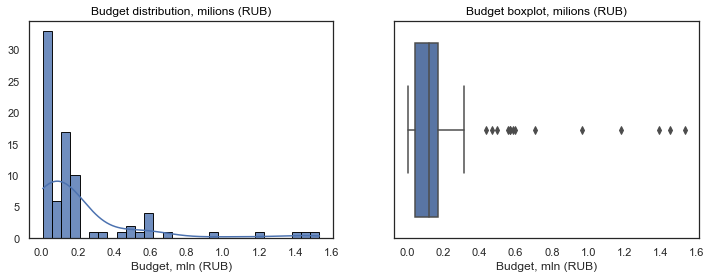

In [17]:
# Budget distribution
campaigns['budget_mln'] = campaigns['budget'] / 1_000_000

sns.set_theme(style="white")
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(campaigns['budget_mln'], bins=30, kde=True, edgecolor='black',alpha=0.8)
plt.title('Budget distribution, milions (RUB)', color='black')
plt.xlabel('Budget, mln (RUB)')
plt.ylabel('')

plt.subplot(1,2,2)
sns.boxplot(x=campaigns['budget_mln'])
plt.title('Budget boxplot, milions (RUB)', color='black')
plt.xlabel('Budget, mln (RUB)')

plt.show()

**Intermediate Conclusion. Campaign Budgets**

The dataset has been filtered for 2024 only, so all records correspond to that year. The number of advertising campaigns is almost evenly distributed throughout the year. Acquisition channels are used fairly evenly, with Google Ads slightly lagging behind the others.

The budget values have a very wide range, from 6.7 k to 1.53 M. The majority of campaign budgets fall within the 40 k–170 k range. A few very large budgets, up to 1.5 M, create a highly skewed distribution.

**Users Data**

In [18]:
print(users.info())
print('\nMissing values:\n', users.isna().sum())
print('\nUnique values:\n', users.nunique())
print('\nSample rows:\n', users.sample(3))
print('\nDuplicates count:', users.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44151 entries, 0 to 44150
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            44151 non-null  int64         
 1   registration_date  44151 non-null  datetime64[ns]
 2   age                44151 non-null  int64         
 3   gender             44151 non-null  object        
 4   region             44151 non-null  object        
 5   acq_channel        44151 non-null  object        
 6   buyer_segment      44151 non-null  object        
 7   cohort_week        44151 non-null  datetime64[ns]
 8   cohort_month       44151 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 3.0+ MB
None

Missing values:
 user_id              0
registration_date    0
age                  0
gender               0
region               0
acq_channel          0
buyer_segment        0
cohort_week          0
cohort_mont

**Intermediate conclusion. Users Data**

The users table contains 9 columns, each with 44,151 rows. There are no missing values in the dataset.

Data types:

- user_id, age - int64,
- registartion_date, cohort_week, cohort_month - datetime64[ns]
- gender, region, acq_channel, buyer_segment - string.

All fields are stored using appropriate data types. The table includes: 6 acquisition channels, 9 regions, 4 buyer segments.

Data covering 12 months. No explicit duplicates were detected.

In [19]:
users["region"].value_counts()

Другие регионы        14516
Москва                10959
Санкт-Петербург        6690
Московская область     3549
Екатеринбург           2145
Нижний Новгород        1748
Новосибирск            1723
Ростов-на-Дону         1423
Краснодар              1398
Name: region, dtype: int64

In [20]:
users["acq_channel"].value_counts()

TikTok             19228
Google Ads          9319
Affiliate           6069
Social Media        4179
SEO                 3312
Email Marketing     2044
Name: acq_channel, dtype: int64

In [21]:
users["buyer_segment"].value_counts()

medium      16421
rare        13256
regular      7773
one_time     6701
Name: buyer_segment, dtype: int64

In [22]:
# Date check
for col in ["registration_date", "cohort_week", "cohort_month"]:
    years = users[col].dt.year.unique()
    print(f"{col}: {sorted(years)}")

registration_date: [2024]
cohort_week: [2024]
cohort_month: [2024]


**Intermediate conclusion**

The lists and counts of unique values across the columns indicate that no noisy or invalid data is present. All records correspond exclusively to the year 2024.

**Events Data**

In [23]:
print(events.info())
print('\nMissing values:\n', events.isna().sum())
print('\nUnique values:\n', events.nunique())
print('\nSample rows:\n', events.sample(3))
print('\nDuplicates count:', events.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785859 entries, 0 to 785858
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      785859 non-null  int64         
 1   user_id       785859 non-null  int64         
 2   event_date    785859 non-null  datetime64[ns]
 3   event_type    785859 non-null  object        
 4   os            785859 non-null  object        
 5   device        785859 non-null  object        
 6   product_name  385740 non-null  object        
 7   event_week    785859 non-null  datetime64[ns]
 8   event_month   785859 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 54.0+ MB
None

Missing values:
 event_id             0
user_id              0
event_date           0
event_type           0
os                   0
device               0
product_name    400119
event_week           0
event_month          0
dtype: int64

Unique values:


**Intermediate conclusion. Events Data**

The event table contains 7 columns and 785,859 rows. There are missing values in the product_name column - 400,119 records.

Data types:

- user_id, age - int64,
- event_date, event_week, event_month - datetime64[ns]
- event_type, os, device, product_name - string.
All fields are stored in appropriate data types. The table includes: 15 events types, 4 operating system, 3 device types. Data covering 12 month. No explicit duplicates were detected.

In [24]:
events['event_type'].value_counts()

page_view            125663
product_view         125318
product_click        121946
add_to_cart          110675
checkout_start        92401
checkout_complete     84012
filter_apply          14243
user_login            14109
category_view         14040
remove_from_cart      14034
user_logout           13981
promo_view            13935
search                13909
banner_click          13826
wishlist_add          13767
Name: event_type, dtype: int64

In [25]:
events['os'].value_counts()

Windows    200499
Android    197945
iOS        195551
macOS      191864
Name: os, dtype: int64

In [26]:
events['device'].value_counts()

mobile     263495
tablet     261288
desktop    261076
Name: device, dtype: int64

In [27]:
# Date check
for col in ["event_date", "event_week", "event_month"]:
    years = events[col].dt.year.unique()
    print(f"{col}: {sorted(years)}")

event_date: [2024]
event_week: [2024]
event_month: [2024]


**Intermediate conclusion**

The lists and counts of unique values across the columns indicate that no noisy or invalid data is present. All records correspond exclusively to the year 2024.

## 2. Key metrics overview

**Overall metrics: DAU, WAU, MAU, Stickiness**

In [28]:
# DAU 
dau = events.groupby('event_date')['user_id'].nunique().reset_index()
dau['event_month'] = dau['event_date'].dt.to_period('M')
dau_month = dau.groupby('event_month')['user_id'].mean().reset_index()
dau_month.columns = ['event_month', 'avg_dau']

# WAU
wau = events.groupby('event_week')['user_id'].nunique().reset_index()
wau['event_month'] = wau['event_week'].dt.to_period('M')
wau_month = wau.groupby('event_month')['user_id'].mean().reset_index()
wau_month.columns = ['event_month', 'avg_wau']

# MAU
mau = events.groupby('event_month')['user_id'].nunique().reset_index()
mau['event_month'] = mau['event_month'].dt.to_period('M') 
mau.columns = ['event_month', 'mau']

metrics = (dau_month.merge(wau_month, on='event_month', how='inner').merge(mau, on='event_month', how='inner'))

# Stickiness
metrics['stickiness'] = metrics['avg_dau'] / metrics['mau']

metrics['month'] = metrics['event_month'].dt.to_timestamp()
metrics = metrics[['month', 'avg_dau', 'avg_wau', 'mau', 'stickiness']]
metrics

,month,avg_dau,avg_wau,mau,stickiness
0,2024-01-01,110.13,459.80,1149,0.10
1,2024-02-01,235.31,905.75,2162,0.11
2,2024-03-01,302.94,"1,129.50",2844,0.11
3,2024-04-01,344.73,"1,275.00",3059,0.11
4,2024-05-01,359.16,"1,328.25",3310,0.11
5,2024-06-01,343.77,"1,289.50",3174,0.11
6,2024-07-01,362.90,"1,387.00",3481,0.10
7,2024-08-01,380.84,"1,451.50",3861,0.10
8,2024-09-01,363.57,"1,422.20",3744,0.10
9,2024-10-01,311.00,"1,287.00",3581,0.09


**Daily Active Users**

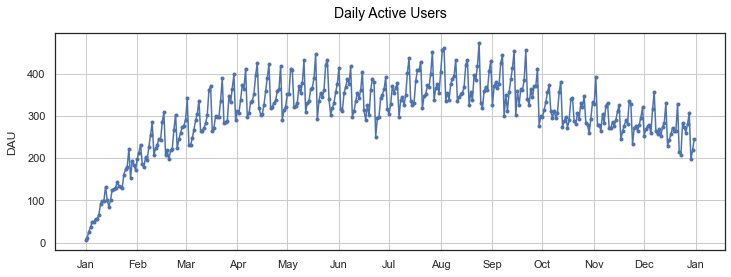

In [29]:
dau_daily = events.groupby('event_date')['user_id'].nunique().reset_index()

plt.figure(figsize=(12,4))
plt.plot(dau_daily['event_date'], dau_daily['user_id'], marker='.')
plt.title('Daily Active Users', pad=15, color='black', fontsize=14)
plt.ylabel('DAU', labelpad=10)
plt.xlabel('')
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

**Intermediate Conclusion**

The DAU chart shows a steady growth from January to May, rising from 0 to 400 daily users.
In June it decreases slightly, but then rises again, reaching a peak in the middle of August with over 450 daily users.
Afterwards, it declines towards December, ending the year at levels similar to February, around 300 daily users.

**Weekly Active Users**

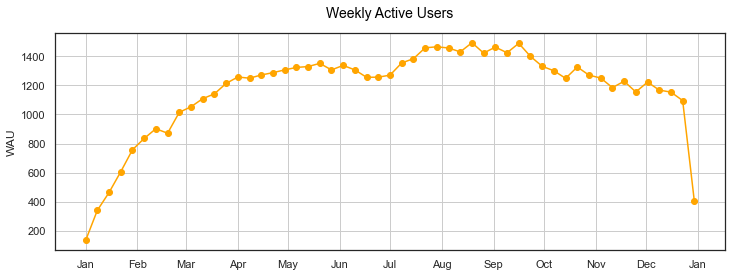

In [30]:
wau_weekly = events.groupby('event_week')['user_id'].nunique().reset_index()

plt.figure(figsize=(12,4))
plt.plot(wau_weekly['event_week'], wau_weekly['user_id'], marker='o', color='orange')
plt.title('Weekly Active Users', pad=15, color='black', fontsize=14)
plt.ylabel('WAU')
plt.xlabel('')
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

**Intermediate conclusion**

The WAU chart shows steady growth from January to mid-August, with minor dips in mid-February and June.
The peak is reached in the middle of August with over 1,4 k weekly users.
Afterwards, the trend declines unevenly, ending the year at around 1,2 k weekly users.

**Monthly Active Users**

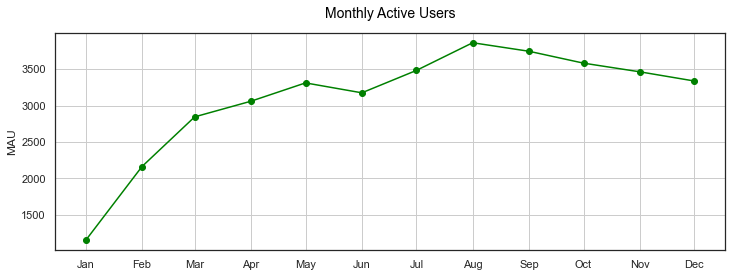

In [32]:
mau_monthly = events.groupby('event_month')['user_id'].nunique().reset_index()
mau_monthly['month'] = mau_monthly['event_month']

plt.figure(figsize=(12,4))
plt.plot(mau_monthly['month'], mau_monthly['user_id'], marker='o', color='green')
plt.title('Monthly Active Users', pad=15, color='black', fontsize=14)
plt.ylabel('MAU')
plt.xlabel('')
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

**Intermediate conclusion**

Monthly user activity grows throughout the year, from 0 in January to nearly 3,5 k users in December.
The peak occurs in August, with around 4 k monthly users.
After the peak, the trend declines towards December, ending slightly above the levels seen in May.

**Stikciness (DAU/MAU) - User Engagement**

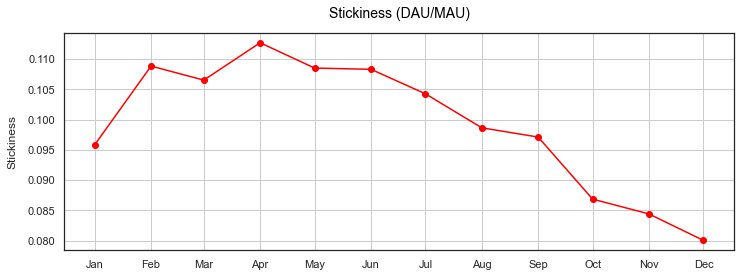

In [33]:
metrics['month_dt'] = pd.to_datetime(metrics['month'])
stickiness_2024 = metrics[(metrics['month_dt'].dt.year == 2024)]

plt.figure(figsize=(12,4))
plt.plot(stickiness_2024['month_dt'], stickiness_2024['stickiness'], marker='o', color='red')
plt.title('Stickiness (DAU/MAU)', pad=15, color='black', fontsize=14)
plt.ylabel('Stickiness', labelpad=10)
plt.xlabel('')
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.show()

**Intermediate Conclusion**

The Stickiness chart shows growth only from January to April, then declines for the rest of the year.
This happens because MAU growth outpaces DAU growth - the product attracts more users, but the new audience is less engaged and visits less frequently.
In absolute terms, user activity increases, but the frequency of usage per user decreases.

**Retention rate**

In [34]:
users['cohort_month'] = users['registration_date'].dt.to_period('M').dt.to_timestamp()
events['event_month'] = events['event_date'].dt.to_period('M').dt.to_timestamp()

# Create cohorts based on registration month
cohorts = users.groupby('cohort_month').agg({'user_id': 'nunique'}).rename(columns={'user_id': 'cohort_size'})

# Merge the data
user_data = users[['user_id', 'cohort_month']]
data = events.merge(user_data, on='user_id', how='inner')

# The difference in months between the event and registration
data['months_diff'] = (data['event_month'].dt.year - data['cohort_month'].dt.year) * 12 \
                    + (data['event_month'].dt.month - data['cohort_month'].dt.month)


cohort_data = data.groupby(['cohort_month', 'months_diff']).agg({'user_id': pd.Series.nunique}).reset_index()

# Merge with cohort size
cohort_data = cohort_data.merge(cohorts, on='cohort_month')
cohort_data['retention'] = cohort_data['user_id'] / cohort_data['cohort_size']

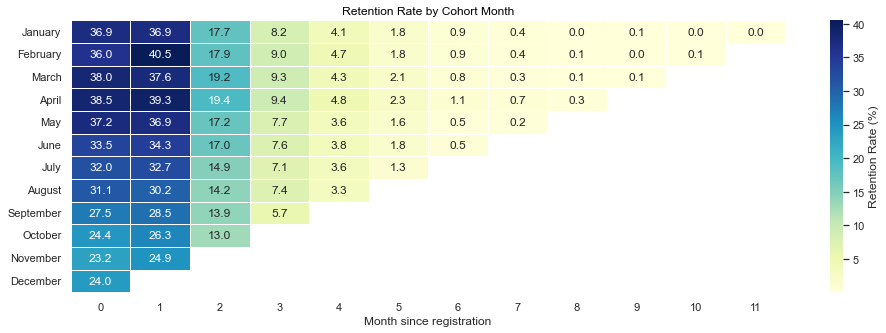

In [144]:
# Create a matrix for the heatmap
retention_matrix = cohort_data.pivot_table(index='cohort_month', columns='months_diff', values='retention', aggfunc='mean')
retention_matrix = retention_matrix * 100
retention_matrix = retention_matrix.replace(0, pd.NA)
retention_matrix.index = pd.to_datetime(retention_matrix.index)
retention_matrix.index = retention_matrix.index.strftime('%B') 

plt.figure(figsize=(16, 5))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate (%)'},
    mask=retention_matrix.isna())

plt.title('Retention Rate by Cohort Month', color='black')
plt.ylabel('')
plt.xlabel('Month since registration')
plt.yticks(rotation=0)
plt.xticks(rotation=0)
plt.show()

**Intermediate Conclusion**

The chart shows that approximately 35-38% of users return in the first month.
However, by the second month, only 17-19% remain active, and by the fourth month, less than 10%.
After the sixth month, retention drops almost to zero.
It is also noticeable that new cohorts start with lower retention levels - 23-27%, which may indicate decreasing user engagement or changes in traffic sources.

**Retention rate - user retention on Day 1, Day 7, and Day 30**

In [35]:
# Truncate the time
users['cohort_day'] = users['registration_date'].dt.to_period('D').dt.to_timestamp()
events['event_day'] = events['event_date'].dt.to_period('D').dt.to_timestamp()

# Count the size of each cohort
cohorts = users.groupby('cohort_day').agg({'user_id': 'nunique'}).rename(columns={'user_id': 'cohort_size'})

# Keep only user_id and registration_date
user_data = users[['user_id', 'cohort_day']]

# Merged data, calcualte difference and filter the required days
data = events.merge(user_data, on='user_id', how='inner')
data['days_diff'] = (data['event_day'] - data['cohort_day']).dt.days
data = data[data['days_diff'].isin([1, 7, 30])]

# Count unique users on the specified days per cohort
cohort_data = data.groupby(['cohort_day', 'days_diff']).agg({'user_id': pd.Series.nunique}).reset_index()
cohort_data = cohort_data.merge(cohorts, on='cohort_day')
cohort_data['retention'] = cohort_data['user_id'] / cohort_data['cohort_size'] * 100

# Calculate average retention across all cohorts
avg_retention = cohort_data.groupby('days_diff')['retention'].mean().reset_index()
avg_retention['days_diff'] = avg_retention['days_diff'].map({1: "D1", 7: "D7", 30: "D30"})

for _, row in avg_retention.iterrows():
    print(f"Retention on {row['days_diff']}: {row['retention']:.1f}%")

Retention on D1: 7.0%
Retention on D7: 6.4%
Retention on D30: 3.5%


**Intermediate Conclusion**

Only 7% of users return the next day, and almost the same - 6.4% after a week.
After 30 days, around 3.5% remain, indicating weak long-term retention.

**Rolling retention**

In [36]:
cohorts = users.groupby('cohort_day').agg({'user_id': 'nunique'}).rename(columns={'user_id': 'cohort_size'})
user_data = users[['user_id', 'cohort_day']]

data = events.merge(user_data, on='user_id', how='inner')
data['days_diff'] = (data['event_day'] - data['cohort_day']).dt.days
data = data[data['days_diff'] >= 0]

rolling_retentions = {}

for day in [1, 7, 30]:
    tmp = (
        data[data['days_diff'] >= day]
        .groupby('cohort_day')['user_id'].nunique()
        .reset_index()
        .rename(columns={'user_id': f'retained_{day}'})
    )
    tmp = tmp.merge(cohorts, on='cohort_day')
    tmp[f'retention_{day}'] = tmp[f'retained_{day}'] / tmp['cohort_size'] * 100
    rolling_retentions[day] = tmp[f'retention_{day}'].mean()

for day in [1, 7, 30]:
    print(f'Rolling Retention on D{day}+ : {rolling_retentions[day]:.1f}%')

Rolling Retention on D1+ : 49.8%
Rolling Retention on D7+ : 44.0%
Rolling Retention on D30+ : 25.6%


**Intermediate Conclusion**

The conversion rate chart shows growth from January to April, with the peak conversion of 31.4% in April.
Afterwards, the conversion rate steadily declines to a minimum of 5.7% in December.

User retention context:

- 50% of users return at least once after the first day.

- 44% of users return at least once within the first week or later.

- 26% of users remain active at least one month after registration.

**Conversion rate**

In [37]:
# Count the size of each cohort
cohorts = users.groupby('cohort_month').agg({'user_id': 'nunique'}).rename(columns={'user_id': 'cohort_size'})

# Merge orders with users
orders_users = orders.merge(users[['user_id', 'cohort_month']], on='user_id', how='inner')

# Count unique users with orders per cohort
cr_per_cohort = orders_users.groupby('cohort_month')['user_id'].nunique().reset_index()
cr_per_cohort.rename(columns={'user_id':'orders_users'}, inplace=True)

# Merge with cohort sizes
cr_per_cohort = cr_per_cohort.merge(cohorts, on='cohort_month')

# Calculate conversion rate (CR)
cr_per_cohort['CR (%)'] = cr_per_cohort['orders_users'] / cr_per_cohort['cohort_size'] * 100
cr_per_cohort['cohort_month_str'] = cr_per_cohort['cohort_month'].dt.strftime('%Y-%m')

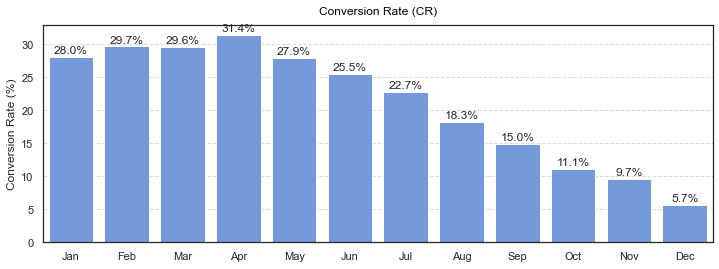

In [38]:
cr_per_cohort['cohort_month_dt'] = pd.to_datetime(cr_per_cohort['cohort_month_str'])
cr_per_cohort['cohort_month_label'] = cr_per_cohort['cohort_month_dt'].dt.strftime('%b')

# Plot
plt.figure(figsize=(12,4))
ax = sns.barplot(x='cohort_month_label', y='CR (%)', data=cr_per_cohort, color='cornflowerblue')
plt.title('Conversion Rate (CR)', pad=10, color='black')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height + 0.5, f"{height:.1f}%", ha="center")

**Intermediate Conclusion**

The purchase conversion chart shows growth from January to April, with a peak conversion of 31.4% in April.
Afterwards, the conversion rate steadily declines to a minimum of 5.7% in December.

## 3. Monetization and unit economics analysis

**Average Revenue Per User**

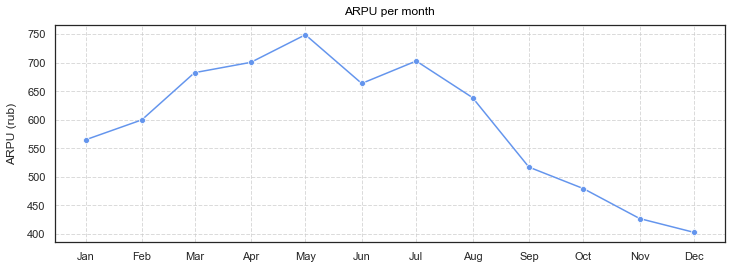

In [39]:
# Revenue (5%)
orders['revenue'] = orders['total_price'] * 0.05

# Add order month
orders['order_month'] = orders['order_date'].dt.to_period('M').dt.to_timestamp()

# Active users per month
active_users = events.groupby(events['event_date'].dt.to_period('M').dt.to_timestamp())['user_id'].nunique().reset_index()
active_users.rename(columns={'user_id': 'active_users', 'event_date': 'month'}, inplace=True)

# Revenue per month
revenue = orders.groupby('order_month')['revenue'].sum().reset_index()
revenue.rename(columns={'order_month': 'month'}, inplace=True)

arpu_data = revenue.merge(active_users, on='month', how='inner')
arpu_data['ARPU'] = arpu_data['revenue'] / arpu_data['active_users']

# Plot
plt.figure(figsize=(12,4))
sns.lineplot(x='month', y='ARPU', data=arpu_data, marker='o', color='cornflowerblue')
plt.title("ARPU per month", pad=10, color='black')
plt.ylabel('ARPU (rub)', labelpad=10)
plt.xlabel('')
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

**Intermediate Conclusion. ARPU**

The Average Revenue Per User (ARPU) chart shows mostly a downward trend.
We observe growth from approximately 570 RUB in January to 750 RUB in May, then, except for a slight increase in June, ARPU declines steadily to 400 RUB by the end of the year.

**Average Revenue Per Paying User**

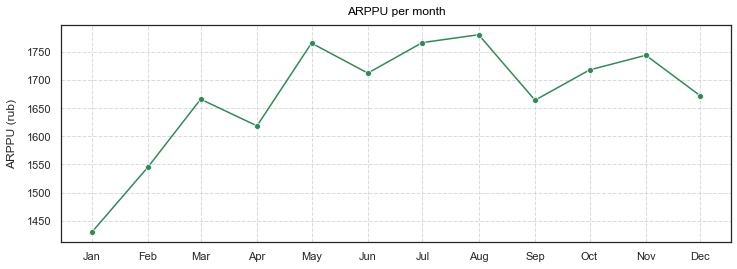

In [40]:
# Revenue per month
revenue = orders.groupby('order_month')['revenue'].sum().reset_index()
revenue.rename(columns={'order_month': 'month'}, inplace=True)

# Paying users per month
paying_users = orders.groupby(orders['order_month'])['user_id'].nunique().reset_index()
paying_users.rename(columns={'user_id': 'paying_users', 'order_month':'month'}, inplace=True)

# Merge and calculate ARPPU
arppu_data = revenue.merge(paying_users, on='month', how='inner')
arppu_data['ARPPU'] = arppu_data['revenue'] / arppu_data['paying_users']

# Plot
plt.figure(figsize=(12,4))
sns.lineplot(x='month', y='ARPPU', data=arppu_data, marker='o', color='seagreen')
plt.title('ARPPU per month', pad=10, color='black')
plt.ylabel('ARPPU (rub)', labelpad=10)
plt.xlabel('')
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.show()

**Intermediate Conclusion. ARPPU**

The ARPPU chart initially follows a pattern similar to ARPU, rising from 1,430 RUB in January to 1,760 RUB in May.
Then it slightly declines, rises again to a peak of 1,770 RUB in August, drops in September to around 1,660 RUB, rises over the next two months to 1,740 RUB, and ends the year at 1,670 RUB.
This metric is influenced by the behavior of paying users, so overall it looks more positive than ARPU.

**Average Order Value**

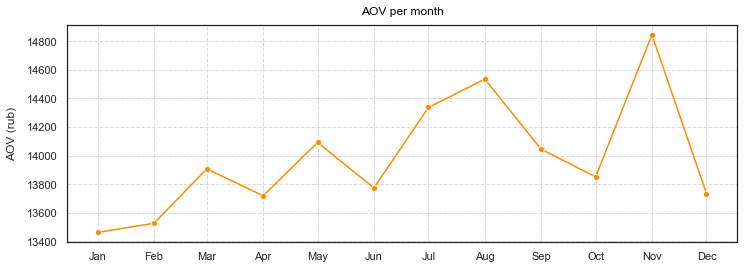

In [41]:
# Calculate AOV
aov_data = orders.groupby('order_month').agg({
    'total_price': 'sum', 
    'order_id': 'count'     
}).reset_index()

aov_data['AOV'] = aov_data['total_price'] / aov_data['order_id']

# Plot
plt.figure(figsize=(12,4))
sns.lineplot(x='order_month', y='AOV', data=aov_data, marker='o', color='darkorange')
plt.title('AOV per month', pad=10, color='black')
plt.ylabel('AOV (rub)', labelpad=10)
plt.xlabel('')
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

**Intermediate Conclusion. AOV**

The average order value shows a fluctuating upward trend from January to August, rising from 13,470 RUB in January to 14,530 RUB in August.
It then declines over the next two months, sharply rises from October to a peak of 14,900 RUB in November, and drops sharply to 13,700 RUB by December.

**LTV - Lifetime value**

In [42]:
# Merge orders with user registration date
orders_with_cohort = orders.merge(users[['user_id', 'registration_date']], on='user_id', how='left')

# Define cohort based on registration month
orders_with_cohort['cohort_month'] = orders_with_cohort['registration_date'].dt.to_period('M').dt.to_timestamp()

# Month of order relative to registration
orders_with_cohort['months_since_registration'] = (
    (orders_with_cohort['order_date'].dt.year - orders_with_cohort['registration_date'].dt.year) * 12 +
    (orders_with_cohort['order_date'].dt.month - orders_with_cohort['registration_date'].dt.month)
)

# Total revenue by cohort and months since registration
cohort_revenue = orders_with_cohort.groupby(['cohort_month', 'months_since_registration'])['revenue'].sum().reset_index()

# Cohort sizes (number of users)
cohort_sizes = users.groupby('cohort_month')['user_id'].nunique().reset_index()
cohort_sizes.columns = ['cohort_month', 'cohort_size']

# Cumulative revenue per cohort
cohort_revenue['cumulative_revenue'] = cohort_revenue.groupby('cohort_month')['revenue'].cumsum()

# Merge with cohort sizes
cohort_ltv = cohort_revenue.merge(cohort_sizes, on='cohort_month')

# Calculate LTV
cohort_ltv['LTV'] = cohort_ltv['cumulative_revenue'] / cohort_ltv['cohort_size']


**LTV chart per cohort**

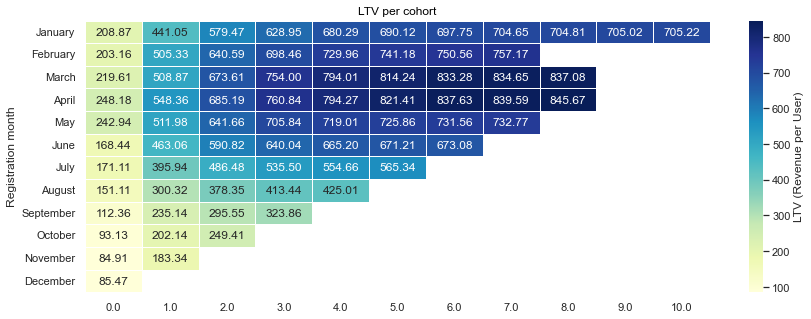

In [43]:
ltv_matrix = cohort_ltv.pivot_table(index='cohort_month', columns='months_since_registration', values='LTV', aggfunc='mean')
ltv_matrix.index = ltv_matrix.index.to_series().dt.strftime('%B')
ltv_matrix_for_plot = ltv_matrix.replace(0, float('nan'))

plt.figure(figsize=(14, 5))
sns.heatmap(
    ltv_matrix_for_plot,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'LTV (Revenue per User)'}
)
plt.title('LTV per cohort', color='black')
plt.ylabel('Registration month')
plt.xlabel('')
plt.show()

**Intermediate Conclusion. LTV**

All cohorts show strong growth in the first two to three months, after which growth slows down but does not stop.

January and February start at similar levels, but February grows faster and reaches 757 RUB by month 7, compared to 704 RUB for January. March and April grow even more, reaching around 840 RUB. May and June are weaker, around 670-730 RUB. From July to September, the figures are even lower, and for October-December, they are less than those of spring cohorts.

Conclusion: Customers generate most of their value in the first three to four months, and the quality of users depends on the month of acquisition or traffic source.

**Customer Acquisition Cost**

In [44]:
# Total marketing spend per month
monthly_spend = campaigns.groupby('spend_month')['budget'].sum().reset_index()

# New users per month
new_users = users.groupby(users['registration_date'].dt.to_period('M').dt.to_timestamp())['user_id'].nunique().reset_index()

new_users.rename(columns={'user_id': 'new_users', 'registration_date': 'month'}, inplace=True)
monthly_spend.rename(columns={'spend_month': 'month'}, inplace=True)

# Merge and calculate CAC
cac_data = monthly_spend.merge(new_users, on='month', how='left')
cac_data['CAC'] = cac_data['budget'] / cac_data['new_users']

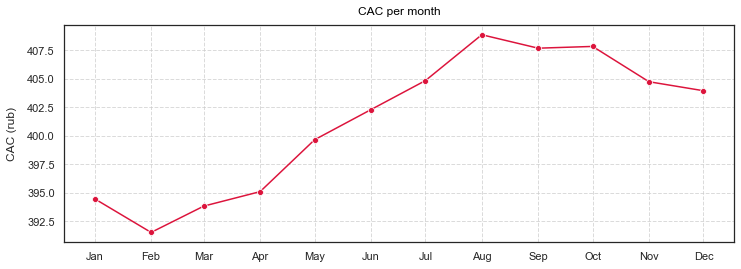

In [45]:
# Plot
plt.figure(figsize=(12,4))
sns.lineplot(x='month', y='CAC', data=cac_data, marker='o', color='crimson')
plt.title('CAC per month', pad=10, color='black')
plt.xlabel('')
plt.ylabel('CAC (rub)', labelpad=10)
plt.xticks(ticks=cac_data['month'], labels=cac_data['month'].dt.strftime('%Y-%m'), rotation=0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

**Intermediate Conclusion. CAC**

Customer acquisition cost ranges from 381 RUB in February to 409 RUB in August. After August, the cost slightly decreases, reaching 404 RUB in December. CAC fluctuates in a narrow range, the maximum and minimum differ by only 7%, indicating that the marketing strategy is stable.

**ROI - Return of investment**

In [46]:
# Merge LTV and CAC by month
roi_data = cohort_ltv.groupby('cohort_month')['LTV'].max().reset_index().merge(
    cac_data[['month', 'CAC']].rename(columns={'month':'cohort_month'}),
    on='cohort_month',
    how='inner'
)

# Calculate ROI
roi_data['ROI'] = (roi_data['LTV'] - roi_data['CAC']) / roi_data['CAC'] *100
roi_data[['cohort_month', 'LTV', 'CAC', 'ROI']]

,cohort_month,LTV,CAC,ROI
0,2024-01-01,705.22,394.46,78.78
1,2024-02-01,757.17,391.51,93.40
2,2024-03-01,837.08,393.82,112.55
3,2024-04-01,845.67,395.09,114.04
4,2024-05-01,732.77,399.65,83.35
5,2024-06-01,673.08,402.29,67.31
6,2024-07-01,565.34,404.84,39.64
7,2024-08-01,425.01,408.86,3.95
8,2024-09-01,323.86,407.68,-20.56
9,2024-10-01,249.41,407.84,-38.85


**ROI chart**

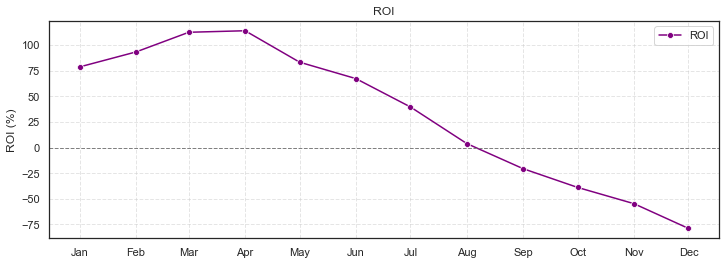

In [48]:
plt.figure(figsize=(12,4))
sns.lineplot(x='cohort_month', y='ROI', data=roi_data, marker='o', color='purple', label='ROI')
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.title("ROI")
plt.xlabel('')
plt.ylabel("ROI (%)")
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

**Intermediate Conclusion. ROI**

The ROI chart shows growth from 75 RUB in January to a peak of 120 RUB in April. Afterwards, ROI declines; by August it reaches the breakeven point, and continues decreasing to 75 RUB in December. From August onward, the months become unprofitable, indicating that newly acquired users have low retention and a small LTV.

**ROI chart per cohort**

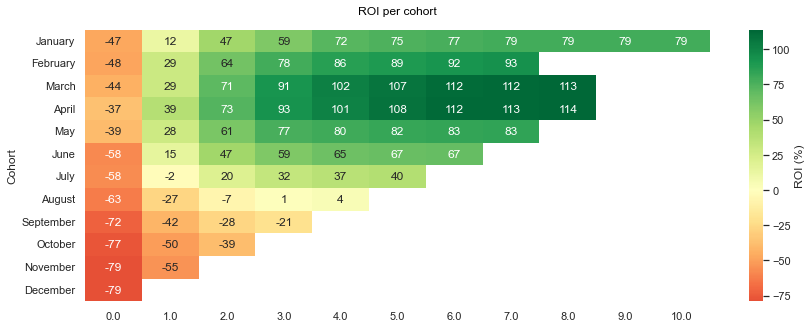

In [49]:
ltv_matrix = cohort_ltv.pivot_table(index='cohort_month',columns='months_since_registration', values='LTV', aggfunc='max')
cac_map = cac_data.set_index('month')['CAC']
roi_matrix = ltv_matrix.sub(cac_map, axis=0).div(cac_map, axis=0) * 100
roi_matrix.index = roi_matrix.index.to_series().dt.strftime('%B')

plt.figure(figsize=(14,5))
sns.heatmap(roi_matrix, annot=True, fmt=".0f", cmap='RdYlGn', center=0, cbar_kws={'label': 'ROI (%)'})
plt.title('ROI per cohort', color='black', fontsize=12, pad=15)
plt.xlabel('')
plt.ylabel('Cohort')
plt.show()

**Intermediate Conclusion. Payback Period**

Cohorts from the first half of the year, January to June, reach breakeven already in the second month. The most successful cohorts are February and March, showing 113 RUB and 114 RUB in payback. The July cohort reaches positive return only in the third month, and the August cohort in the fourth month. The remaining cohorts do not achieve breakeven by the end of the year.

**Payback period**

In [50]:
# Cumulative LTV
cohort_ltv['cum_LTV'] = cohort_ltv.groupby('cohort_month')['LTV'].cumsum()

# Add CAC to each cohort
merged = cohort_ltv.merge(
    cac_data[['month', 'CAC']].rename(columns={'month':'cohort_month'}),
    on='cohort_month',
    how='left'
)

# First month when LTV >= CAC
merged['crossed'] = merged['cum_LTV'] >= merged['CAC']
payback_months = merged[merged['crossed']].groupby('cohort_month')['months_since_registration'].min()

# Average Payback Period
avg_payback = payback_months.mean()
print(f'Average Payback Period: {avg_payback:.2f} months')

Average Payback Period: 1.20 months


**Intermediate Conclusion. Payback Period**

On average, customer acquisition investments pay back in just over one month.
However, the payback period varies significantly across cohorts: cohorts from the first half of the year become profitable, while autumn and winter cohorts remain unprofitable.

**New User Registration Dynamics**

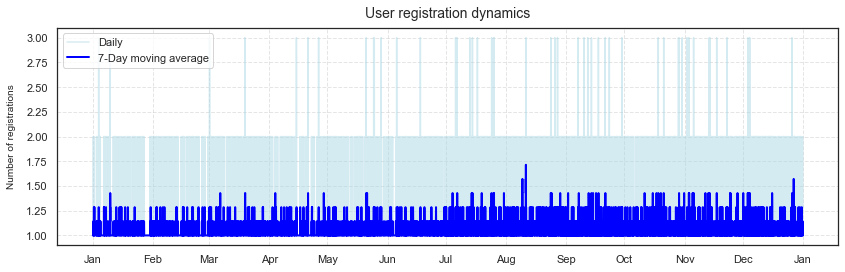

In [51]:
# Daily dynamics and moving average
daily = users.groupby('registration_date').size()
window = 7
daily_smoothed = daily.rolling(window=window).mean()

plt.figure(figsize=(14,4))
plt.plot(daily.index, daily.values, color='lightblue', alpha=0.5, label='Daily')
plt.plot(daily_smoothed.index, daily_smoothed.values, color='blue', linewidth=2, label='7-Day moving average')
plt.title('User registration dynamics', pad=10, fontsize=14)
plt.xlabel('')
plt.ylabel('Number of registrations', fontsize=10, labelpad=10)
plt.legend()
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

In [52]:
avg_daily = daily.mean()
min_daily = daily.min()
max_daily = daily.max()

print(f'Average registration per day: {avg_daily:.0f}')
print(f'Minimum: {min_daily}')
print(f'Maximum: {max_daily}')

Average registration per day: 1
Minimum: 1
Maximum: 3


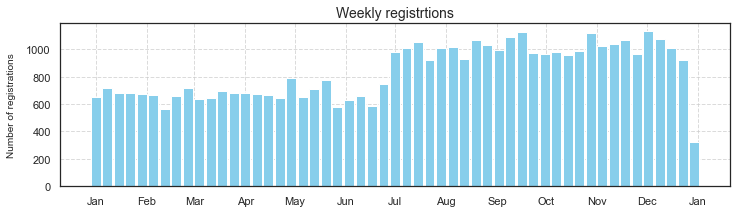

In [53]:
# Weekly dynamics
weekly = users.groupby('cohort_week').size()

plt.figure(figsize=(12,3))
plt.bar(weekly.index, weekly.values, width=6, color='skyblue') 
plt.title('Weekly registrtions', fontsize=14)
plt.ylabel('Number of registrations', fontsize=10, labelpad=10)
plt.xlabel('')
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.7)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

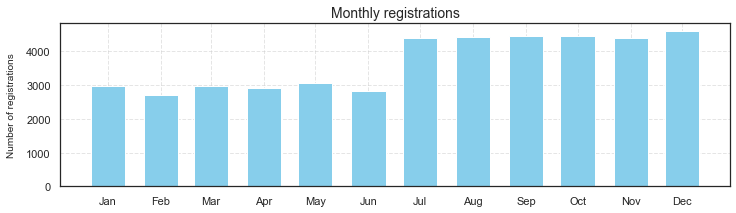

In [54]:
# Monthly dynamics
monthly = users.groupby('cohort_month').size()
monthly.index = pd.to_datetime(monthly.index)

plt.figure(figsize=(12, 3))
plt.bar(monthly.index, monthly.values, width=20, color='skyblue')
plt.title('Monthly registrations', fontsize=14)
plt.ylabel('Number of registrations', fontsize=10, labelpad=10)
plt.xlabel('')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.5)

**Intermediate Conclusion. Registration dynamics**

Across all registration charts, we observe that active user growth starts in July and remains at approximately the same level until the end of the year.

### Conclusions for Stages 2 and 3

**1. User Activity**
- User activity increased from January to May/August: DAU grew to ~450, WAU to ~1,450, and MAU to ~4,000.
- After peaking in August, user activity declined toward the end of the year:
- DAU dropped to ~300, WAU to ~1,200, and MAU to ~3,500.
- User engagement started to decline after April.

User acquisition continued to grow, but engagement and retention of newly acquired users deteriorated toward the end of the year.

**2. User Retention**
- 35–38% of users return in the first month, 17–19% in the second month, less than 10% by the fourth month, and almost zero after the sixth month.
- Autumn and winter cohorts start with lower retention (23–27%), indicating either lower engagement or a change in traffic sources.

Low multi-month retention significantly limits user lifetime revenue and reduces the efficiency of acquisition investments.

**3. Conversion and Revenue**

- Purchase conversion rate increased from January to April (peaking at 31.4%) and then declined to 5.7% by December.
- Average revenue per user (ARPU) grew from January to May, from 570 RUB to 750 RUB, and then declined to 400 RUB by December.
- Revenue per paying user (ARPPU) increased until August (up to 1,770 RUB), followed by minor fluctuations and a decline toward year-end (1,670 RUB).
- Average order value (AOV) rose from January (13,470 RUB) to a peak in November (14,900 RUB) and declined in December (13,700 RUB).

Revenue growth in the first half of the year was driven by strong spring cohorts, while autumn and winter cohorts generated less revenue due to lower engagement and declining conversion.

**4. Lifetime Revenue per User and Investment Efficiency**

- LTV shows strong growth in the first two to three months, after which growth slows down.
- The best-performing cohorts are February, March, and April.
- CAC remains relatively stable, with fluctuations of about 7%.
- ROI is positive for January–June cohorts and turns negative from August through December.
- The average payback period is 1.2 months.

**Key Findings**

**1. Core Issue: Low-Quality Traffic Starting April–June 2024**
- The period from January to April demonstrates the highest acquisition efficiency: strong DAU/WAU/MAU growth, peak conversion rates, LTV, and positive ROI.From June to December, especially in autumn and winter, performance deteriorates: slower payback, lower retention, and negative ROI.

- The data indicates that a major shift in user acquisition strategy occurred around April–June, negatively affecting overall product performance. Key quality metrics—purchase conversion and retention—begin to decline already in April, meaning the problem started before the visible traffic growth in June. In June, the issue escalates as the team sharply increases marketing spend in an attempt to offset declining performance, leading to an influx of low-quality traffic. As a result, stickiness decreases (users return less frequently), and purchase conversion drops as fewer new users become paying customers.

**2. Negative Impact on Core Metrics**
- Revenue decline: Lower traffic quality led to fewer orders and declining revenue.
- While ARPPU remains relatively stable, ARPU drops sharply due to the decrease in paying users.
- Retention rate decline: Post-April cohorts show significantly lower repeat purchase behavior.
- LTV decline: A noticeable decrease begins in May, with a sharper drop from June onward.

**3. Decline in Marketing Efficiency**
- ROI, the key marketing efficiency metric, starts declining in April and turns negative from August to December, meaning marketing investments no longer pay off.
- CAC remains relatively stable, increasing by only about 7% from February to August.
- The core issue lies not in the product itself, but in an ineffective user growth strategy.
- The marketplace attracts a large number of low-value and non-loyal users, which leads to declining revenue.
- Further analysis with deeper user segmentation is required.

## 4. Segmentation, insight discovery, and hypothesis generation

After completing the high-level data assessment, we move from the general picture to more granular observations.
We dive deeper into the data and perform segmentation.

Goal - to formulate data-driven hypotheses:

- which segments perform better than others

- which segments perform worse

- at which funnel stages users drop off

- which groups can or should be scaled

- where to invest more attention or resources

**1. Segmentation**

**1.1 Acquisition Channel Analysis**

**1.1.1 Revenue by Acquisition Channel**

In [207]:
# Revenue per user
user_revenue = orders.groupby('user_id')['revenue'].sum().reset_index()
users_orders = users.merge(user_revenue, on='user_id', how='left')

# Unique users and total revenue by channel
channel_summary = users_orders.groupby('acq_channel').agg({
    'user_id': 'nunique',
    'revenue': 'sum'
}).rename(columns={'user_id': 'users'}).reset_index()

# Paying user by channel
paying_users = users_orders[users_orders['revenue'] > 0].groupby('acq_channel')['user_id'].nunique().reset_index()
paying_users.rename(columns={'user_id': 'paying_users'}, inplace=True)

channel_summary = channel_summary.merge(paying_users, on='acq_channel')

# ARPU и ARPPU
channel_summary['avg_revenue_per_user'] = channel_summary['revenue'] / channel_summary['users']
channel_summary['arppu'] = channel_summary['revenue'] / channel_summary['paying_users']
channel_summary_sorted = channel_summary.sort_values('avg_revenue_per_user', ascending=False).reset_index(drop=True)

channel_summary_sorted

,acq_channel,users,revenue,paying_users,avg_revenue_per_user,arppu
0,Affiliate,6069,"6,735,814.78",2338,"1,109.87","2,881.02"
1,Google Ads,9319,"8,236,760.24",3187,883.87,"2,584.49"
2,Social Media,4179,"3,000,254.74",1211,717.94,"2,477.50"
3,SEO,3312,"1,909,934.75",874,576.67,"2,185.28"
4,Email Marketing,2044,"555,698.74",325,271.87,"1,709.84"
5,TikTok,19228,"910,448.21",719,47.35,"1,266.27"


**1.1.2 Revenue and User Count by Acquisition Channel**

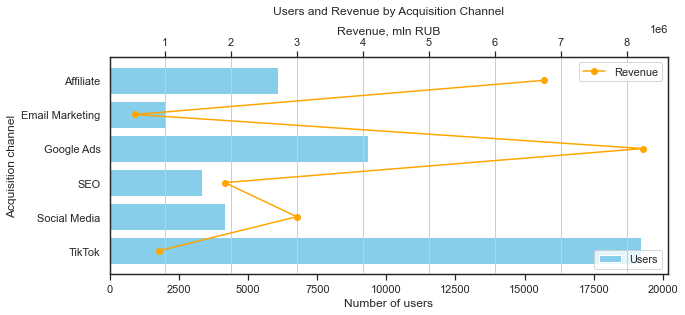

In [208]:
fig, ax1 = plt.subplots(figsize=(10,4))

ax1.barh(channel_summary['acq_channel'], channel_summary['users'], color='skyblue', label='Users')
ax1.set_xlabel('Number of users')
ax1.set_ylabel('Acquisition channel')
ax1.invert_yaxis() 

ax2 = ax1.twiny()
ax2.plot(channel_summary['revenue'], channel_summary['acq_channel'], color='orange', marker='o', label='Revenue')
ax2.set_xlabel('Revenue, mln RUB')
ax1.legend(loc='lower right')
ax2.legend(loc='upper right')

plt.title('Users and Revenue by Acquisition Channel', pad=10)
plt.grid(axis='x')
plt.show()

**Intermediate Conclusion**

The chart shows that acquisition channels differ significantly in effectiveness.

Google Ads generates the highest total revenue - over 8 million RUB, followed by Affiliate with approximately 7 million RUB.
However, Affiliate brings higher-quality users, as its average revenue per paying user (ARPPU) of 2,881 RUB exceeds Google Ads 2 584 RUB per user by 11.5%.

The least efficient channel is TikTok. While it attracts the largest number of users (19.2k users), its total revenue is only 910k RUB, exceeding only Email Marketing (555k RUB). TikTok also has the lowest ARPPU - 1,266 RUB per paying user.

The number of paying users further confirms this pattern:
Affiliate brings 2,338 paying users, which is more than three times higher than TikTok, which has only 719 paying users.

**1.1.3 New Users by Acquisition Channel**

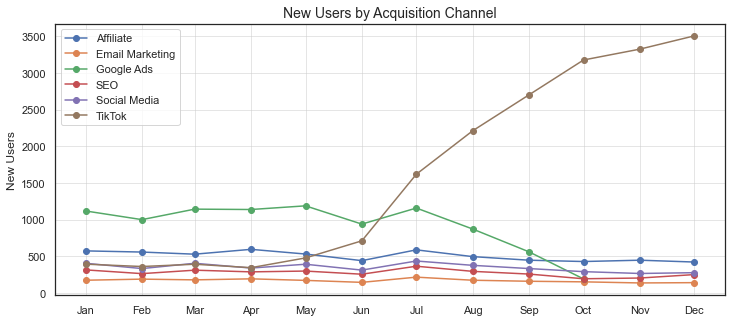

In [211]:
# Registration month
users['registration_month'] = pd.to_datetime(users['registration_date']).dt.to_period('M')
# New users trend by month and channel
new_users_trend = (
    users.groupby(['registration_month', 'acq_channel'])['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id':'new_users'})
)
plt.figure(figsize=(12, 5))

for channel in new_users_trend['acq_channel'].unique():
    subset = new_users_trend[new_users_trend['acq_channel'] == channel]
    months = subset['registration_month'].dt.to_timestamp()
    plt.plot(months, subset['new_users'], marker='o', label=channel)

plt.title('New Users by Acquisition Channel', fontsize=14)
plt.ylabel('New Users')
plt.xlabel('')
plt.grid(alpha=0.5)
plt.legend()
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

**Intermediate Conclusion**

The TikTok channel demonstrates strong and consistent growth. A small increase starts as early as April, but in June we observe a sharp upward trend that continues until the end of the year, reaching approximately 3,5 k new users in December.
For comparison, the closest channel - Google Ads - reaches a maximum of only around 1,2 l users in May.

In June, all channels show some growth, although it is relatively minor compared to TikTok. Starting from July, most channels return to their previous levels and remain fairly stable overall.
Google Ads is the only channel that declines from July to October and does not recover in terms of new user acquisition afterward.

**1.1.4. Share of Monthly Advertising spend by channel**

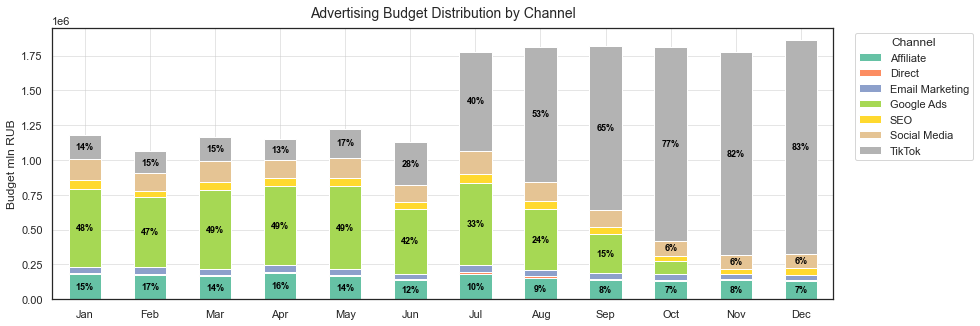

In [213]:
# Budget by month and channel
budget_table = campaigns.groupby(['spend_month', 'acq_channel'])['budget'].sum().reset_index()
budget_pivot = budget_table.pivot_table(index='spend_month', columns='acq_channel',values='budget',fill_value=0).sort_index()

# Plot
ax = budget_pivot.plot(kind='bar', stacked=True, figsize=(14,5), colormap='Set2')
plt.title('Advertising Budget Distribution by Channel', pad=10, fontsize=14)
plt.xlabel('')
plt.ylabel('Budget mln RUB')
plt.legend(title='Channel', loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(alpha=0.5)
ax.set_xticks(range(len(budget_pivot.index)))
ax.set_xticklabels([d.strftime('%b') for d in budget_pivot.index], rotation=0)

totals = budget_pivot.sum(axis=1)
for i, month in enumerate(budget_pivot.index):
    month_values = budget_pivot.loc[month].sort_values(ascending=False)
    top_channels = month_values.index[:3]
    bottom = 0
    for channel in budget_pivot.columns:
        value = budget_pivot.loc[month, channel]
        if value > 0:
            if channel in top_channels:
                percent = value / totals[i] * 100
                ax.text(i, bottom + value/2, f'{percent:.0f}%', ha='center', va='center',
                        fontsize=9, color='black', fontweight='bold')
            bottom += value
plt.show()

**Intermediate Conclusion**

The chart shows that starting from June, the advertising budget distribution begins to shift in favor of TikTok.
In May, TikTok accounts for 17% of total ad spend, while by the end of the year its share increases dramatically to 83% of the total budget.

**1.1.5 Share of Paying Users by acquisition channel**

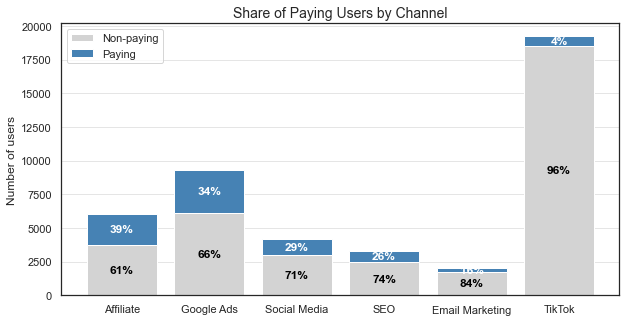

In [215]:
# Calculate number of non-paying users
channel_summary_sorted['non_paying_users'] = channel_summary_sorted['users'] - channel_summary_sorted['paying_users']
users_matrix = channel_summary_sorted[['acq_channel', 'non_paying_users', 'paying_users']]
users_matrix.set_index('acq_channel', inplace=True)

# График
fig, ax = plt.subplots(figsize=(10,5))
bottom = np.zeros(len(users_matrix))
colors = ['lightgray', 'steelblue']

for i, col in enumerate(['non_paying_users', 'paying_users']):
    ax.bar(users_matrix.index, users_matrix[col], bottom=bottom, color=colors[i], label=col)
    for j, value in enumerate(users_matrix[col]):
        if value > 0:
            total = users_matrix.iloc[j].sum()
            percent = value / total * 100
            ax.text(
                j, bottom[j] + value/2,
                f'{percent:.0f}%',
                ha='center', va='center', color='white' if col=='paying_users' else 'black', fontweight='bold')
    bottom += users_matrix[col]
plt.ylabel('Number of users')
plt.title('Share of Paying Users by Channel', fontsize=14)
plt.legend(['Non-paying', 'Paying'], loc='upper left')
plt.grid(axis='y', alpha=0.5)
plt.xticks(rotation=0)
plt.show()

**Intermediate Conclusion**

This chart clearly shows that TikTok is the least effective channel in terms of attracting paying users: only 4% of users become paying customers. Despite having the largest total user volume, the number of paying users is minimal.

The Affiliate channel brings in almost 40% paying users, making it 10 times more effective than TikTok in conversion to payment.
Google Ads follows with 34% paying users, while Social Media (29%) and SEO (26%) can also be considered relatively effective channels.

**1.1.6 Paying Users Trend by Month**

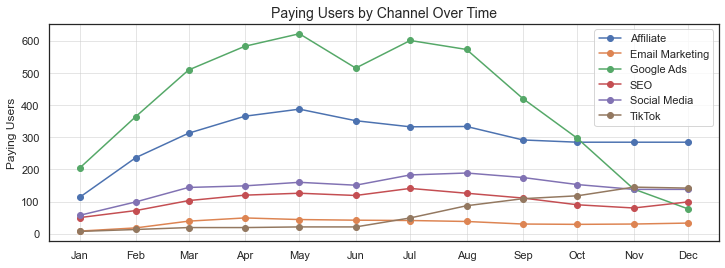

In [217]:
# Order month
orders['order_month'] = pd.to_datetime(orders['order_date']).dt.to_period('M')
# Merge orders with acquisition channel
orders_users = orders.merge(users[['user_id','acq_channel']], on='user_id', how='left')
# Paying users trend by month and channel
paying_users_trend = (
    orders_users.groupby(['order_month','acq_channel'])['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id':'paying_users'})
)
plt.figure(figsize=(12, 4))

for channel in paying_users_trend['acq_channel'].unique():
    subset = paying_users_trend[paying_users_trend['acq_channel'] == channel]
    months = subset['order_month'].dt.to_timestamp()
    plt.plot(months, subset['paying_users'], marker='o', label=channel)

plt.title('Paying Users by Channel Over Time', fontsize=14)
plt.ylabel('Paying Users')
plt.xlabel('')
plt.grid(alpha=0.5)
plt.legend()
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

**Intermediate Conclusion**

From January to May, all channels show growth in the number of paying users.

- Google Ads starts as the strongest channel with around 200 paying users in January, peaks in May at ~620, and then declines (with a slight correction in July) until December, reaching only ~80 paying users. It shows the most negative dynamics in the second half of the year.

- Affiliate is the most stable channel for attracting paying users. It also grows until May and then gradually declines toward the end of the year. Values range from 100 to 400, finishing the year at around 300 paying users.

- TikTok begins generating paying users only from June onward and shows steady growth from zero to ~150 paying users by December.

- Other channels remain relatively stable, fluctuating between 0 and 150 paying users per month.

In August, all channels decline except TikTok.

**1.1.7. Conversion to Purchase by Channel**

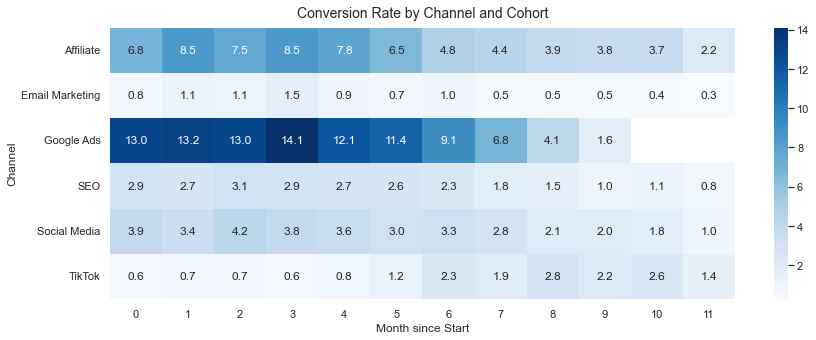

In [219]:
# Cohort sizes
cohorts = users.groupby(['cohort_month']).agg({'user_id': 'nunique'}).rename(columns={'user_id': 'cohort_size'}).reset_index()

# Add channel info to users
users_channels = users[['user_id', 'cohort_month', 'acq_channel']]

# Orders + channel + cohort
orders_users = orders.merge(users_channels, on='user_id', how='inner')

# Unique users with orders by cohort and channel
orders_per_channel = (
    orders_users.groupby(['cohort_month','acq_channel'])['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id':'orders_users'})
)

# Merge cohort sizes
orders_per_channel = orders_per_channel.merge(cohorts, on='cohort_month', how='left')

# Conversion Rate calculation
orders_per_channel['CR (%)'] = orders_per_channel['orders_users'] / orders_per_channel['cohort_size'] * 100

heatmap_data = orders_per_channel.pivot(index='acq_channel', columns='cohort_month', values='CR (%)')
heatmap_data.columns = range(len(heatmap_data.columns))
plt.figure(figsize=(14,5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='Blues')
plt.title('Conversion Rate by Channel and Cohort', pad=10, fontsize=14)
plt.xlabel('Month since Start')
plt.ylabel('Channel')
plt.show()

**Intermediate Conclusion**

The strongest channel is Google Ads, with a conversion rate of 13-14 RUB per user in the first four months, after which it declines sharply to around 1.6 RUB.

The weakest channels are:

- Email Marketing, with a conversion rate of 0.5-1.5 RUB

- TikTok, with conversion ranging from 0.6 to a maximum of 2.8 RUB

A key insight is that retention requires improvement, as a noticeable drop after the first month is observed across all channels.

**1.2. Customer Segmennts**

In [220]:
# By customer segments
segment_summary = users_orders.groupby('buyer_segment').agg({
    'user_id': 'nunique',
    'revenue': 'sum'
}).reset_index()
segment_summary.rename(columns={'user_id': 'users'}, inplace=True)
segment_summary['avg_revenue_per_user'] = segment_summary['revenue'] / segment_summary['users']

segment_summary

,buyer_segment,users,revenue,avg_revenue_per_user
0,medium,16421,"5,190,507.73",316.09
1,one_time,6701,"221,051.71",32.99
2,rare,13256,"1,046,909.80",78.98
3,regular,7773,"14,890,442.21","1,915.66"


**Average Revenue by User Segment (Chart)**

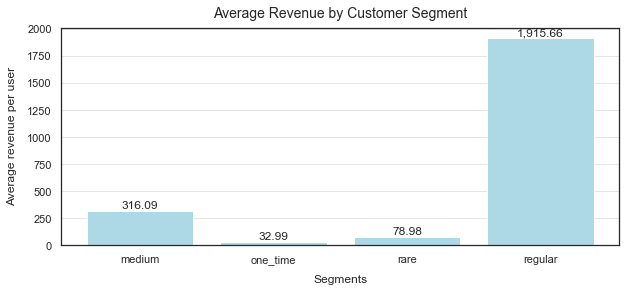

In [222]:
plt.figure(figsize=(10, 4))
bars = plt.bar(segment_summary['buyer_segment'], segment_summary['avg_revenue_per_user'], color='lightblue')

plt.title('Average Revenue by Customer Segment', pad=10, fontsize=14)
plt.ylabel('Average revenue per user', labelpad=10)
plt.xlabel('Segments', labelpad=10)
plt.grid(axis='y', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:,.2f}", ha='center', va='bottom')

plt.show()

**Intermediate Conclusions**

This chart clearly shows how important it is for the marketplace to retain regular customers.
Revenue from this segment is about 1,900 RUB per user, which is six times higher than the next most valuable segment - medium, whose users bring around 316 RUB on average.

Rare users are four times less valuable than medium users, generating only about 80 RUB, while one-time buyers generate very little value - around 30 RUB per user.

**1.3. Age-Based Data**

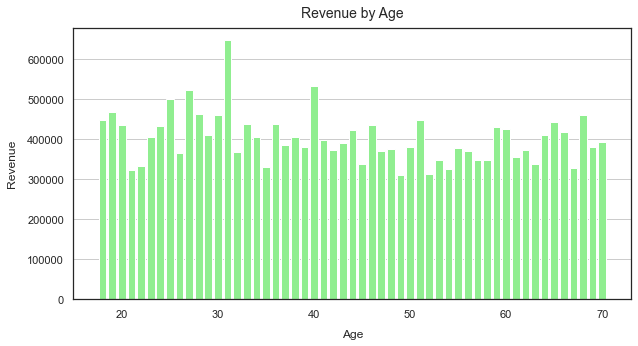

In [224]:
# Revenue distribution by age
age_summary = users_orders.groupby('age').agg({
    'user_id': 'nunique',
    'revenue': 'sum'
}).reset_index()
age_summary.rename(columns={'user_id': 'users'}, inplace=True)
age_summary['avg_revenue_per_user'] = age_summary['revenue'] / age_summary['users']

plt.figure(figsize=(10,5))
plt.bar(age_summary['age'], age_summary['revenue'], color='lightgreen')
plt.title('Revenue by Age', pad=10, fontsize=14)
plt.xlabel('Age', labelpad=10)
plt.ylabel('Revenue', labelpad=10)
plt.grid(axis='y')

**Intermediate Conclusions**

The chart does not show a clear dependency between revenue size and age group.
The leading age is 31 years, with total revenue of 6.5 million RUB, followed by 40-year-old customers with approximately 5.3 million RUB.

**1.4. Gender-Based Data**

In [225]:
# Revenue distribution by gender
gender_summary = users_orders.groupby('gender').agg({
    'user_id': 'nunique',
    'revenue': 'sum'
}).reset_index()
gender_summary.rename(columns={'user_id': 'users'}, inplace=True)
gender_summary['avg_revenue_per_user'] = gender_summary['revenue'] / gender_summary['users']

gender_summary

,gender,users,revenue,avg_revenue_per_user
0,F,22126,"10,834,445.40",489.67
1,M,22025,"10,514,466.05",477.39


**Intermediate Conclusion**

When analyzing revenue by customer gender, we see that female users generate on average 12 RUB more revenue than male users.
At the same time, the number of female users is only about 100 users higher than male users on the marketplace.

**1.5. Regional Data**

In [226]:
# User and revenue distribution by region
region_summary = users_orders.groupby('region').agg({
    'user_id': 'nunique',
    'revenue': 'sum'
}).reset_index()
region_summary.rename(columns={'user_id': 'users'}, inplace=True)
region_summary['avg_revenue_per_user'] = region_summary['revenue'] / region_summary['users']
region_summary_sorted = region_summary.sort_values('avg_revenue_per_user', ascending=False).reset_index(drop=True)

region_summary_sorted

,region,users,revenue,avg_revenue_per_user
0,Екатеринбург,2145,"1,143,765.90",533.22
1,Краснодар,1398,"728,837.63",521.34
2,Санкт-Петербург,6690,"3,396,292.58",507.67
3,Москва,10959,"5,410,184.15",493.67
4,Нижний Новгород,1748,"841,422.00",481.36
5,Другие регионы,14516,"6,837,361.32",471.02
6,Московская область,3549,"1,658,614.02",467.35
7,Ростов-на-Дону,1423,"603,704.79",424.25
8,Новосибирск,1723,"728,729.05",422.94


**Regional Data Distribution Chart**

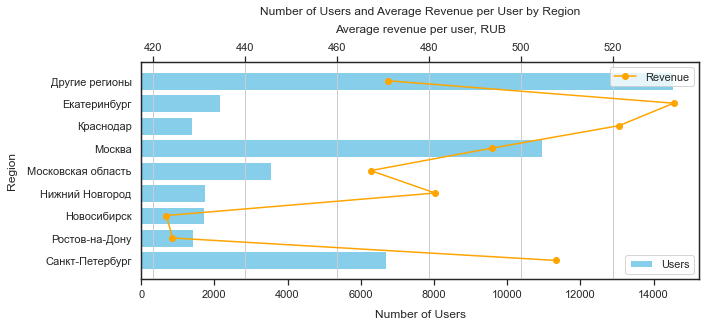

In [228]:
fig, ax1 = plt.subplots(figsize=(10,4))

ax1.barh(region_summary['region'], region_summary['users'], color='skyblue', label='Users')
ax1.set_xlabel('Number of Users', labelpad=10)
ax1.set_ylabel('Region', labelpad=10)
ax1.invert_yaxis() 

ax2 = ax1.twiny()
ax2.plot(region_summary['avg_revenue_per_user'], region_summary['region'], color='orange', marker='o', label='Revenue')
ax2.set_xlabel('Average revenue per user, RUB', labelpad=10)
ax1.legend(loc='lower right')
ax2.legend(loc='upper right')

plt.title('Number of Users and Average Revenue per User by Region', pad=10)
plt.grid(axis='x')
plt.show()

**Intermediate Conclusion**

- The leaders in terms of the number of users and total revenue are Other Regions, with 14.5 k users and total revenue of 6.8 million RUB. Second place is Moscow, with 11 thousand users and total revenue of 5.4 million RUB. Third place is Saint Petersburg, with 6.7 k users and 3.4 million RUB in revenue.

- The chart shows differences in the user base.The most profitable users are in Yekaterinburg, bringing the service an average of 533 RUB per user, followed by Krasnodar with 521 RUB, and Saint Petersburg, also in third place, with 507 RUB in revenue per user.

- The lowest revenue comes from Rostov-on-Don, with only 603 thousand RUB in total revenue and 424 RUB per user, and Novosibirsk, with 728 thousand RUB and 422 RUB per user.

**1.6. Product Category Data**

In [229]:
# Revenue by category
user_revenue_cat = orders.groupby(['user_id', 'category_name'])['revenue'].sum().reset_index()

summary_by_category = user_revenue_cat.groupby('category_name').agg({
    'user_id': 'nunique', 
    'revenue': 'sum'     
}).reset_index()

summary_by_category.rename(columns={'user_id': 'users'}, inplace=True)
summary_by_category['avg_revenue_per_user'] = summary_by_category['revenue'] / summary_by_category['users']
summary_by_category_sorted = summary_by_category.sort_values('revenue', ascending=False).reset_index(drop=True)

summary_by_category_sorted.head(10)

,category_name,users,revenue,avg_revenue_per_user
0,Мебель для дома,514,"3,580,998.22","6,966.92"
1,Бытовая техника,546,"2,248,933.06","4,118.93"
2,Украшения и часы,495,"1,718,297.10","3,471.31"
3,Спортивный инвентарь,523,"1,165,361.15","2,228.22"
4,Товары для туризма,498,"1,137,317.79","2,283.77"
5,Автотовары,561,"1,044,821.74","1,862.43"
6,Товары для кухни,637,"1,030,401.81","1,617.59"
7,Обувь мужская,730,"942,481.68","1,291.07"
8,Сумки и аксессуары,711,"873,491.14","1,228.54"
9,Обувь женская,757,"860,489.19","1,136.71"


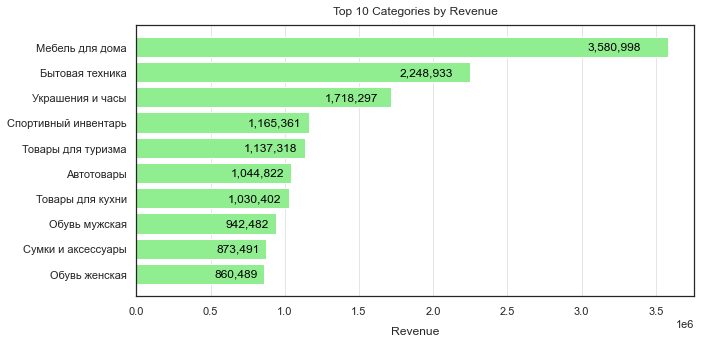

In [231]:
top10_categories = summary_by_category.sort_values('revenue', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(top10_categories['category_name'], top10_categories['revenue'], color='lightgreen')
plt.title('Top 10 Categories by Revenue', pad=10)
plt.xlabel('Revenue', labelpad=10)
plt.ylabel('')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.5)

for i, v in enumerate(top10_categories['revenue']):
    plt.text(v * 0.95, i, f"{v:,.0f}", va='center', ha='right', color='black')


**Intermediate Conclusion**

The leading product categories on the marketplace are:

- Home Furniture - 3.5 million RUB

- Home Appliances - 2.2 million RUB

- Jewelry and Watches - 1.7 million RUB

These categories generate the highest share of total revenue and represent the core monetization drivers of the platform.

**1.7. Product-level Analysis**

In [69]:
user_revenue_cat = orders.groupby(['user_id', 'product_name'])['revenue'].sum().reset_index()

summary_by_product = user_revenue_cat.groupby('product_name').agg({
    'user_id': 'nunique', 
    'revenue': 'sum'     
}).reset_index()

summary_by_product.rename(columns={'user_id': 'users'}, inplace=True)
summary_by_product['avg_revenue_per_user'] = summary_by_product['revenue'] / summary_by_product['users']
summary_by_product_sorted = summary_by_product.sort_values('revenue', ascending=False).reset_index(drop=True)

summary_by_product_sorted.head(10)

,product_name,users,revenue,avg_revenue_per_user
0,Диван угловой,108,"799,154.75","7,399.58"
1,Тумба ТВ,115,"575,890.10","5,007.74"
2,Стол обеденный,101,"482,995.42","4,782.13"
3,Кровать двуспальная,84,"469,972.56","5,594.91"
4,Шкаф-купе,105,"401,430.88","3,823.15"
5,Часы Casio,126,"395,390.11","3,138.02"
6,Комод с ящиками,104,"388,605.33","3,736.59"
7,Фен для волос,106,"387,223.80","3,653.05"
8,Цепочка серебряная,109,"358,495.49","3,288.95"
9,Пылесос робот,123,"333,911.54","2,714.73"


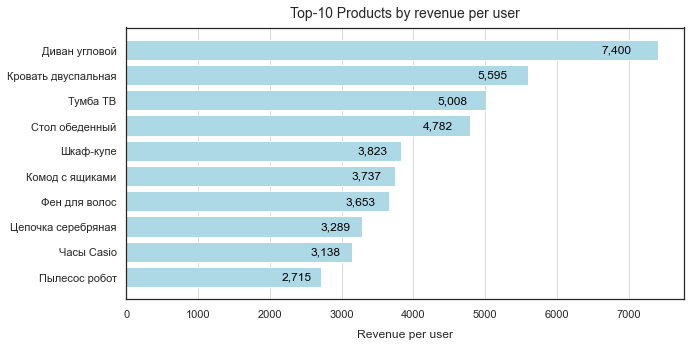

In [233]:
top10_product = summary_by_product.sort_values('revenue', ascending=False).head(10)
top10_product = top10_product.sort_values('avg_revenue_per_user', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(top10_product['product_name'], top10_product['avg_revenue_per_user'], color='lightblue')
plt.title('Top-10 Products by revenue per user', pad=10, fontsize=14)
plt.xlabel('Revenue per user', labelpad=10)
plt.ylabel('')
plt.grid(axis='x', alpha=0.7)

for i, v in enumerate(top10_product['avg_revenue_per_user']):
    plt.text(v * 0.95, i, f"{v:,.0f}", va='center', ha='right', color='black')

**Intermediate Conclusion**

Among the top-performing products, the leading positions are dominated by items from the Home Furniture category. These products generate the highest revenue per user, confirming that furniture is the most valuable product group for the marketplace.

**1.8. Device Analysis**

In [234]:
user_revenue = orders.groupby('user_id')['revenue'].sum().reset_index()
user_device = events.sort_values('event_date').drop_duplicates('user_id')[['user_id', 'device']]

user_device = user_device.merge(user_revenue, on='user_id', how='left')

summary_by_device = user_device.groupby('device').agg(
    users=('user_id', 'nunique'),
    revenue=('revenue', 'sum')
).reset_index()

summary_by_device['avg_revenue_per_user'] = summary_by_device['revenue'] / summary_by_device['users']
summary_by_device_sorted = summary_by_device.sort_values('avg_revenue_per_user', ascending=False).reset_index(drop=True)

summary_by_device_sorted

,device,users,revenue,avg_revenue_per_user
0,tablet,7260,"6,795,250.25",935.98
1,mobile,7431,"6,678,642.78",898.75
2,desktop,7447,"6,547,252.32",879.18


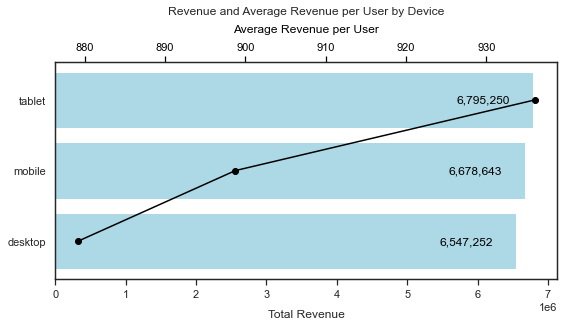

In [235]:
top_device_sorted = summary_by_device_sorted.sort_values('revenue', ascending=False)

fig, ax1 = plt.subplots(figsize=(9, 4))

ax1.barh(top_device_sorted['device'], top_device_sorted['revenue'], color='lightblue')
ax1.set_xlabel('Total Revenue', labelpad=10)
ax1.set_title('Revenue and Average Revenue per User by Device', pad=10)
ax1.invert_yaxis()

for i, v in enumerate(top_device_sorted['revenue']):
    ax1.text(v * 0.95, i, f"{v:,.0f}", va='center', ha='right', color='black')

ax2 = ax1.twiny()
ax2.plot(top_device_sorted['avg_revenue_per_user'], top_device_sorted['device'], color='black', marker='o')
ax2.set_xlabel("Average Revenue per User", color='black', labelpad=10)
ax2.tick_params(axis='x', colors='black')

**Intermediate Conclusion. Devices**

Revenue is relatively evenly distributed across devices. Tablet users generate the highest total revenue and also demonstrate the highest average revenue per user, despite having a slightly smaller user base compared to mobile and desktop users.

**1.9. Operating System Analysis**

In [73]:
# Calculate total revenue per user
user_revenue = orders.groupby('user_id')['revenue'].sum().reset_index()

# Identify the primary operating system for each user
user_os = events.sort_values('event_date').drop_duplicates('user_id')[['user_id', 'os']]

# Merge operating system data with user-level revenue
user_os = user_os.merge(user_revenue, on='user_id', how='left')

# Aggregate number of users and total revenue by operating system
summary_by_os = user_os.groupby('os').agg(
    users=('user_id', 'nunique'),
    revenue=('revenue', 'sum')
).reset_index()

# Calculate average revenue per user
summary_by_os['avg_revenue_per_user'] = summary_by_os['revenue'] / summary_by_os['users']

summary_by_os_sorted = summary_by_os.sort_values('avg_revenue_per_user', ascending=False).reset_index(drop=True)
summary_by_os_sorted

,os,users,revenue,avg_revenue_per_user
0,macOS,5418,"5,050,384.76",932.15
1,iOS,5603,"5,214,976.92",930.75
2,Android,5523,"5,069,056.18",917.81
3,Windows,5594,"4,686,727.49",837.81


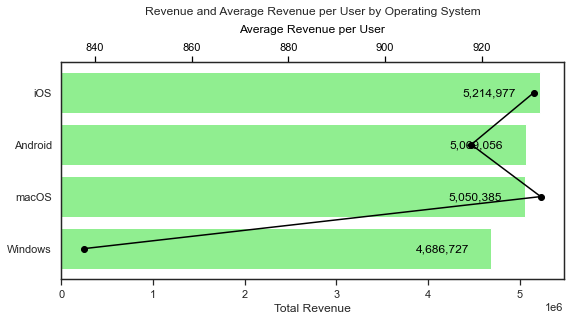

In [236]:
top_os_sorted = summary_by_os_sorted.sort_values('revenue', ascending=False)

fig, ax1 = plt.subplots(figsize=(9, 4))

ax1.barh(top_os_sorted['os'], top_os_sorted['revenue'], color='lightgreen')
ax1.set_xlabel('Total Revenue')
ax1.set_title('Revenue and Average Revenue per User by Operating System', pad=10)
ax1.invert_yaxis()

for i, v in enumerate(top_os_sorted['revenue']):
    ax1.text(v * 0.95, i, f"{v:,.0f}", va='center', ha='right', color='black')

ax2 = ax1.twiny()
ax2.plot(top_os_sorted['avg_revenue_per_user'], top_os_sorted['os'], color='black', marker='o')
ax2.set_xlabel('Average Revenue per User', color='black', labelpad=10)
ax2.tick_params(axis='x', colors='black')


**Intermediate Conclusion**

Overall, average revenue per user for macOS, iOS, and Android users is very similar, ranging from approximately 920 to 930 RUB. Windows users generate noticeably lower revenue per user, at around 840 RUB. The number of users across operating systems is distributed fairly evenly, with each OS having roughly 5.4 k – 5.6 k users.

**2. User Journey Funnel**

**2.1. Classic Funnel**

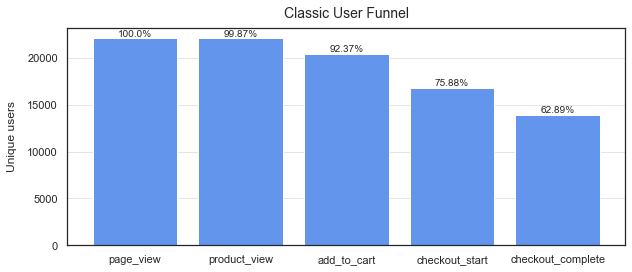

In [238]:
# Funnel stages
funnel_steps = ['page_view', 'product_view', 'add_to_cart', 'checkout_start', 'checkout_complete']

# Filter events related to funnel steps
funnel_df = events[events['event_type'].isin(funnel_steps)]

# Group by funnel stage and count unique users
funnel_counts = funnel_df.groupby('event_type')['user_id'].nunique().reindex(funnel_steps).reset_index()
funnel_counts = funnel_counts.rename(columns={'user_id': 'user_n'})

# Calculate conversion rate from the first funnel step
funnel_counts['conversion_from_start_%'] = (funnel_counts['user_n'] / funnel_counts['user_n'].iloc[0] * 100).round(2)

plt.figure(figsize=(10, 4))
bars = plt.bar(funnel_counts['event_type'], funnel_counts['user_n'], color='cornflowerblue')
plt.title('Classic User Funnel', pad=10, fontsize=14)
plt.ylabel('Unique users', labelpad=10)
plt.grid(axis='y', alpha=0.5)

for bar, pct in zip(bars, funnel_counts['conversion_from_start_%']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{pct}%', 
             ha='center', va='bottom', fontsize=10)


**Intermediate Conclusion**

The classic funnel shows that 92% of users who visit the website reach the stage of adding items to the cart. About 75% of users start the checkout process, and 63% of all visitors complete the purchase, which can be considered a strong overall conversion rate.

**2.2  Step-by-Step Funnel**

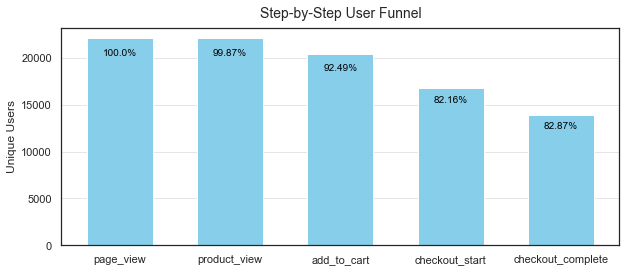

In [241]:
# Funnel stages
funnel_steps = ['page_view', 'product_view', 'add_to_cart', 'checkout_start', 'checkout_complete']

# Filter events related to funnel steps
funnel_df = events[events['event_type'].isin(funnel_steps)]

# Group funnel steps and count unique users
funnel_counts = funnel_df.groupby('event_type')['user_id'].nunique().reindex(funnel_steps).reset_index()
funnel_counts = funnel_counts.rename(columns={'user_id': 'user_n'})

# Calculate conversion rates between consecutive funnel stages
conversion_from_previous = funnel_counts['user_n'].copy()
conversion_from_previous[1:] = (funnel_counts['user_n'][1:].values / funnel_counts['user_n'][:-1].values * 100).round(2)
conversion_from_previous[0] = 100 

plt.figure(figsize=(10,4))
bars = plt.bar(funnel_counts['event_type'], funnel_counts['user_n'], color='skyblue', width=0.6)
plt.title('Step-by-Step User Funnel', pad=10, fontsize=14)
plt.ylabel('Unique Users')
plt.grid(axis='y', alpha=0.5)

for bar, pct in zip(bars, conversion_from_previous):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()*0.95, f"{pct}%", 
             ha='center', va='top', color='black', fontsize=10)


**Intermediate Conclusion**

The step-by-step funnel indicates that approximately 7% of users are lost between product viewing and adding items to the cart. Around 18% of users who add items to the cart do not proceed to checkout, and an additional 17% of users who start checkout fail to complete the purchase, dropping off at the final stage.

**2.3 Step-by-Step Funnel by Acquisition Channel**

In [242]:
# Funnel stages
funnel_steps = ['page_view', 'product_view', 'add_to_cart', 'checkout_start', 'checkout_complete']

# List of acquisition channels
channels = users['acq_channel'].unique()

funnel_table = pd.DataFrame(columns=funnel_steps, index=channels)

# Calculate step-by-step conversion rates for each acquisition channel
for channel in channels:
    channel_users = users[users['acq_channel'] == channel]['user_id']
    channel_events = events[(events['user_id'].isin(channel_users)) & (events['event_type'].isin(funnel_steps))]
    
    funnel_counts = (channel_events.groupby('event_type')['user_id'].nunique() .reindex(funnel_steps)) 
    conv_prev = funnel_counts.copy()
    conv_prev[1:] = (funnel_counts[1:] / funnel_counts[:-1].values * 100).round(1)
    conv_prev[0] = 100 
    funnel_table.loc[channel] = conv_prev

funnel_table

,page_view,product_view,add_to_cart,checkout_start,checkout_complete
Google Ads,100.00,99.90,95.30,87.50,87.80
Email Marketing,100.00,100.00,95.10,86.40,84.90
Affiliate,100.00,99.90,96.10,88.80,88.50
SEO,100.00,99.90,96.80,88.60,87.40
Social Media,100.00,100.00,94.20,84.10,84.60
TikTok,100.00,99.70,85.20,68.10,68.40


**Intermediate Conclusion**

All acquisition channels except TikTok demonstrate very similar funnel performance. Approximately 85–88% of users who start the checkout process complete a purchase. TikTok performs significantly worse: only about 68% of users proceed to checkout, and roughly the same share completes the purchase.

**2.4. Step-by-Step Funnel by Region**

In [243]:
# Define funnel steps
funnel_steps = ['page_view', 'product_view', 'add_to_cart', 'checkout_start', 'checkout_complete']

# List of regions
regions = users['region'].unique()

funnel_table = pd.DataFrame(columns=funnel_steps, index=regions)

# Calculate step-by-step conversion rates for each region
for region in regions:
    # Select users from the given region
    region_users = users[users['region'] == region]['user_id']
    # Filter events for selected users and funnel steps
    region_events = events[(events['user_id'].isin(region_users)) & (events['event_type'].isin(funnel_steps))]
     # Count unique users at each funnel step
    funnel_counts = region_events.groupby('event_type')['user_id'].nunique().reindex(funnel_steps)
    # Calculate conversion from the previous step
    conv_prev = funnel_counts.copy()
    conv_prev[1:] = (funnel_counts[1:] / funnel_counts[:-1].values * 100).round(0)
    conv_prev[0] = 100
    # Store results as percentages
    funnel_table.loc[region] = conv_prev.astype(int).astype(str)

funnel_table

,page_view,product_view,add_to_cart,checkout_start,checkout_complete
Москва,100,100,92,82,82
Санкт-Петербург,100,100,92,82,82
Краснодар,100,100,94,81,83
Другие регионы,100,100,93,82,83
Нижний Новгород,100,100,93,84,83
Екатеринбург,100,100,92,83,83
Московская область,100,100,93,82,83
Новосибирск,100,100,92,82,84
Ростов-на-Дону,100,100,91,77,82


**Intermediate Conclusion**

The funnel performance is generally stable across regions, with no major drop-offs observed. The only noticeable deviation appears in Rostov-on-Don at the checkout_start stage, where conversion is lower. This may indicate regional specifics such as UX issues, delivery availability, or payment method limitations. Additional data would be required for deeper investigation.

**2.5. Step-by-Step Funnel by Device Type**

In [79]:
# Define funnel steps
funnel_steps = ['page_view', 'product_view', 'add_to_cart', 'checkout_start', 'checkout_complete']

# List of device types
devices = events['device'].unique()
funnel_table = pd.DataFrame(columns=funnel_steps, index=devices)

# Calculate step-by-step conversion rates for each device type
for device in devices:
    device_events = events[(events['device'] == device) & (events['event_type'].isin(funnel_steps))]
    
    funnel_counts = device_events.groupby('event_type')['user_id'].nunique().reindex(funnel_steps)

    conv_prev = funnel_counts.copy()
    conv_prev[1:] = (funnel_counts[1:] / funnel_counts[:-1].values * 100).round(0)
    conv_prev[0] = 100
    
    # Store results as percentages
    funnel_table.loc[device] = conv_prev.astype(int).astype(str)

funnel_table

,page_view,product_view,add_to_cart,checkout_start,checkout_complete
mobile,100,100,92,81,83
desktop,100,100,92,83,84
tablet,100,100,93,82,82


**Intermediate Conclusion**

The funnel is stable across all device types. No anomalies or significant differences in user behavior are observed between mobile, desktop, and tablet users.

**2.6 Step-by-Step Funnel by Operating System**

In [244]:
# Define funnel steps
funnel_steps = ['page_view', 'product_view', 'add_to_cart', 'checkout_start', 'checkout_complete']

# List of operating systems
os_list = events['os'].unique()
funnel_table_os = pd.DataFrame(columns=funnel_steps, index=os_list)

# Calculate step-by-step conversion rates for each operating system
for os_name in os_list:
    
    # Filter events by operating system and funnel steps
    os_events = events[(events['os'] == os_name) & (events['event_type'].isin(funnel_steps))]
    
    # Count unique users at each funnel step
    funnel_counts = os_events.groupby('event_type')['user_id'].nunique().reindex(funnel_steps)
    
    # Calculate conversion from the previous step
    conv_prev = funnel_counts.copy()
    conv_prev[1:] = (funnel_counts[1:] / funnel_counts[:-1].values * 100).round(0)
    conv_prev[0] = 100 
    
    # Store results as percentages
    funnel_table_os.loc[os_name] = conv_prev.astype(int).astype(str)

funnel_table_os

,page_view,product_view,add_to_cart,checkout_start,checkout_complete
iOS,100,100,92,82,82
Windows,100,100,93,82,82
macOS,100,100,92,82,83
Android,100,100,93,82,84


**Intermediate Conclusion**

The funnel shows consistent performance across all operating systems. No significant drop-offs or anomalies are observed, indicating similar user behavior regardless of OS.

### Conclusions for Stage 4

**Key Findings**

**1. Acquisition Channels**

- Google Ads generates the highest total revenue (over 8 million RUB), but its average revenue per paying user is lower than that of Affiliate.

- Affiliate is the highest-quality channel: it has the highest average revenue per user and accounts for nearly 40% of all paying users.

- TikTok is a highly inefficient channel: it brings the largest user volume (19,000+ users) but the lowest total revenue (910 thousand RUB) and the lowest revenue per paying user. At the same time, TikTok receives 83% of the total advertising budget by the end of the year, indicating significant overspending with minimal return.

- Email Marketing and Social Media provide a stable inflow of users but show relatively low conversion.

- Recommendation: scale Affiliate, maintain Google Ads, and reallocate budget away from TikTok.

**2. Time Dynamics**

- From January to May, all channels show growth, peaking in May.

- Starting in June, TikTok demonstrates rapid growth in new users, but not in revenue.

- Google Ads declines steadily from May through December.

- Affiliate remains relatively stable but also declines after spring.

- In the second half of the year, traffic quality deteriorates due to budget reallocation toward TikTok.

**3. User Funnel**

On average across the marketplace, 63% of users who open the site complete a purchase.

Main drop-offs:

- 7% between product view and add to cart
- 18% add items to the cart but do not start checkout
- 17% start checkout but do not complete the purchase

- By channel: all channels except TikTok complete purchases in 85–88% of cases after checkout starts; TikTok’s conversion at this stage is about 20% lower.
- By region: the funnel is generally stable, except for Rostov-on-Don, where a drop occurs at the start of checkout, suggesting possible local issues.
- By device and operating system: no anomalies observed; funnels are stable.

Overall, the funnel shows no systemic issues, but TikTok traffic and Rostov-on-Don require further investigation.

**4. User Behavior**

- Regular customers generate 6× more revenue than the medium segment and tens of times more than one-time buyers.
- There is no strong correlation between revenue and age group.
- Female users generate slightly higher revenue per user than male users, but the difference is not significant.
- The main growth opportunity lies in customer retention.

**5. Geography**

Leaders by user count and total revenue are:

- Other Regions (6.8 million RUB)

- Moscow (5.4 million RUB)

- Saint Petersburg (3.4 million RUB)

The highest average revenue per user is observed in Yekaterinburg, Krasnodar, and Saint Petersburg (510–530 RUB).The weakest regions are Rostov-on-Don and Novosibirsk.Marketing efforts should be strengthened in Yekaterinburg and Krasnodar, while Rostov-on-Don requires diagnostic analysis.

**6. Categories and Products**

Top revenue-generating categories:

- Home Furniture (5.3 million RUB)
- Home Appliances (2.2 million RUB)
- Jewelry and Watches (1.7 million RUB)

All top-5 products by revenue belong to the Home Furniture category.Furniture is the key revenue-driving category.

**7. Devices and Operating Systems**

- Users are distributed relatively evenly across devices and operating systems.

- Tablet users generate slightly higher revenue.

No critical UX issues are identified across devices or operating systems.

**Hypotheses**

- TikTok checkout incentives
If users acquired via TikTok are offered a personalized discount or free delivery directly at the checkout stage, conversion to purchase will increase, as the funnel drop occurs specifically at this step.

- Improving TikTok traffic quality
If TikTok campaigns are retargeted toward audiences similar to paying users from Google Ads and Affiliate, conversion to payment will increase. TikTok brings a large volume of users but very few paying customers.

- Retention through personalization
If personalized offers are introduced for users with repeat sessions, average order value and LTV will increase, since regular customers generate 6× more revenue than the medium segment.

- Rostov-on-Don optimization
If delivery and payment options for Rostov-on-Don are reviewed and optimized, checkout conversion will increase to the regional average level.

- Promotion of key categories
If marketing support for the top category Home Furniture is increased and cross-selling with home appliances is implemented, overall revenue growth will exceed the market average rate.

## 5. Experiment setup and results evaluation

### New Data:
```python
pa_marketplace_events_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_events_AB.csv')
pa_marketplace_orders_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_orders_AB.csv')
pa_marketplace_users_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_users_AB.csv')
```
### The split results are stored in the following table:
```python
pa_marketplace_AB_split_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_AB_split_users.csv')
```
* user_id – user identifier
* group – experiment group assigned to the user

### Experiment Design: First-Purchase Bonus for TikTok Users

### 1. Context and Experiment Goal
- **Business context:**
The product team is launching an experiment aimed at increasing conversion among users acquired through the TikTok channel. To stimulate the first purchase, users are offered a bonus for their first order.
- **Goal:**
To evaluate whether offering a first-purchase bonus impacts conversion and revenue among TikTok users.
- **Hypothesis:**
Providing a bonus for the first purchase to new users acquired via TikTok will increase the conversion rate to the first purchase.
---
### 2. Experiment Format

- **Experiment type:** Rolling split experiment

- **Channel:** TikTok users only

- **Groups:**
- Control group (A): TikTok users without a bonus
- Test group (B): TikTok users with a first-purchase bonus

- **Allocation:** Even distribution of new TikTok users between groups based on registration date

- **Duration:** 3 weeks (fixed period)

### 3. Key Metrics
#### Primary Metric

- **Conversion to first purchase** - the share of users acquired via TikTok who made their first purchase

**Objective:** increase conversion using the bonus

**Success criterion:** statistically significant increase in conversion in the test group

#### Secondary Metrics

- **ARPU** - average revenue per TikTok user

- **ARPPU** - average revenue per paying TikTok user

- **AOV** -average order value for TikTok users

#### Guardrail Metric: 
 - Total revenue from TikTok users
---
### 4. Group Sizes and Launch

- **Target audience:** TikTok users only

- **Group sizes:** determined by the actual TikTok traffic during the experiment period

- **Comment:** the experiment was launched without a preliminary power analysis or MDE calculation due to urgency

In [245]:
# Load new data
pa_marketplace_events_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_events_AB.csv', parse_dates=['event_date', 'event_week','event_month'])
pa_marketplace_orders_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_orders_AB.csv',parse_dates=['order_date', 'order_week','order_month'])
pa_marketplace_users_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_users_AB.csv', parse_dates=['registration_date', 'cohort_week','cohort_month'])
pa_marketplace_AB_split_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_AB_split_users.csv')

In [248]:
# Rename datasets
events_AB = pa_marketplace_events_AB
orders_AB = pa_marketplace_orders_AB
users_AB = pa_marketplace_users_AB
AB = pa_marketplace_AB_split_users

In [249]:
# Inspect events data
events_AB.info()
print('\nDuplicates count:', events_AB.duplicated().sum())
events_AB.sample(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831231 entries, 0 to 831230
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      831231 non-null  int64         
 1   user_id       831231 non-null  int64         
 2   event_date    831231 non-null  datetime64[ns]
 3   event_type    831231 non-null  object        
 4   os            831231 non-null  object        
 5   device        831231 non-null  object        
 6   product_name  409054 non-null  object        
 7   event_week    831231 non-null  datetime64[ns]
 8   event_month   831231 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 57.1+ MB

Duplicates count: 0


,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
397580,245373,9101,2024-07-12 16:39:00,product_click,Android,mobile,Лопата штыковая,2024-07-08,2024-07-01
253466,173544,6614,2024-05-16 11:21:14,page_view,iOS,desktop,NaN,2024-05-13,2024-05-01
385870,411049,15421,2024-07-07 19:39:10,add_to_cart,macOS,mobile,Костюм для мальчика,2024-07-01,2024-07-01


In [250]:
# Inspect orders data
orders_AB.info()
print('\nDuplicates count:', orders_AB.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33280 entries, 0 to 33279
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       33280 non-null  int64         
 1   user_id        33280 non-null  int64         
 2   order_date     33280 non-null  datetime64[ns]
 3   product_name   33280 non-null  object        
 4   quantity       33280 non-null  int64         
 5   unit_price     33280 non-null  float64       
 6   total_price    33280 non-null  float64       
 7   category_name  33280 non-null  object        
 8   order_week     33280 non-null  datetime64[ns]
 9   order_month    33280 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.5+ MB

Duplicates count: 0


In [251]:
# Unspect users data
users_AB.info()
print('\nDuplicates count:', users_AB.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22196 entries, 0 to 22195
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            22196 non-null  int64         
 1   registration_date  22196 non-null  datetime64[ns]
 2   age                22196 non-null  int64         
 3   gender             22196 non-null  object        
 4   region             22196 non-null  object        
 5   acq_channel        22196 non-null  object        
 6   buyer_segment      22196 non-null  object        
 7   cohort_week        22196 non-null  datetime64[ns]
 8   cohort_month       22196 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 1.5+ MB

Duplicates count: 0


In [252]:
# Inspect A/B split table
AB.info()
print('\nDuplicates count:', AB.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2968 entries, 0 to 2967
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  2968 non-null   int64 
 1   group    2968 non-null   object
dtypes: int64(1), object(1)
memory usage: 46.5+ KB

Duplicates count: 0


**Intermediate Conclusion**

All tables contain complete data.Logical missing values are present only in the events_AB dataset, in the product_name column for events without direct product interaction. No explicit duplicates were found. All date fields are consistently converted to the datetime64[ns] type.

**Prepare the data for running the experiment**

In [253]:
# Filter experiment participants and merge with A/B split table
exp_users = users_AB.merge(AB, on='user_id', how='inner')
exp_users = exp_users[exp_users['acq_channel'] == 'TikTok']
print('Number of experiment participants:', exp_users.shape[0])

# Number of users in each group
group_counts = exp_users.groupby('group')['user_id'].count()
print('\nGroup distribution:')
for grp, cnt in group_counts.items():
    print(f"{grp}: {cnt}")

# Attach orders to experiment users
orders_AB['order_date_dt'] = pd.to_datetime(orders_AB['order_date'], errors='coerce')
exp_orders = orders_AB.merge(exp_users[['user_id','group']], on='user_id', how='inner')
print('Number of orders by experiment participants:', exp_orders.shape[0])

# Number of unique A/B users with orders
exp_orders_user_ids = exp_orders['user_id'].nunique()
print('Unique A/B users with orders:', exp_orders_user_ids)

Number of experiment participants: 2968

Group distribution:
control: 1503
treatment: 1465
Number of orders by experiment participants: 255
Unique A/B users with orders: 126


In [256]:
# Experiment dates
print(exp_users['registration_date'].min(), exp_users['registration_date'].max())

2025-01-01 00:05:00 2025-01-26 23:41:00


In [257]:
# Checking for group overlap
users_A = set(exp_users.loc[exp_users['group'] == 'control', 'user_id'])
users_B = set(exp_users.loc[exp_users['group'] == 'treatment', 'user_id'])

overlap = users_A.intersection(users_B)

print(f'Users assigned to both groups: {len(overlap)}')

Users assigned to both groups: 0


**Intermediate Conclusion**

- Experiment group sizes are comparable: 1,503 users in control and 1,465 in treatment.

- No user overlap between groups.

- Experiment period: January 1, 2025 - January 26, 2025.

**Primary Metric**

In [258]:
# Revenue equals 5% of total_price
exp_orders['revenue'] = exp_orders['total_price'] * 0.05

# Conversion calculation
exp_users['made_order'] = exp_users['user_id'].isin(exp_orders['user_id']).astype(int)
exp_conv = exp_users.groupby('group')['made_order'].mean() * 100

print('Conversion by group (%):')
for grp, conv in exp_conv.items():
    print(f'{grp}: {conv:.2f}%')

Conversion by group (%):
control: 1.06%
treatment: 7.51%


**Statistical Test**
**Hypotheses**

- H₀ (Null hypothesis):
Conversion in the treatment group is less than or equal to conversion in the control group; the bonus has no effect.

- H₁ (Alternative hypothesis):
Conversion in the treatment group is higher than in the control group; the bonus increases conversion.

In [259]:
groups = exp_users.groupby('group')['made_order'].agg(['sum','count']).reindex(['control','treatment'])
successes = groups['sum'].values.astype(int)
nobs = groups['count'].values.astype(int)

stat, pval = proportions_ztest(successes, nobs, alternative='smaller')

print(f'Z-test (H1: treatment > control): stat={stat:.3f}, p-value={pval:.6f}')

if pval < 0.05:
    print('Conclusion: H1 accepted - the bonus statistically significantly increased conversion.')
else:
    print('Conclusion: H0 accepted - no statistically significant increase in conversion detected.')


Z-test (H1: treatment > control): stat=-8.705, p-value=0.000000
Conclusion: H1 accepted - the bonus statistically significantly increased conversion.


**Intermediate Conclusion**

Conversion in the treatment group reached 7.5%, compared to 1.0% in the control group.
The statistical test confirms that the difference is statistically significant.

Therefore, we can conclude that introducing a first-purchase bonus effectively increases conversion among TikTok users.

**Secondary Metrics**

In [92]:
# ARPU 
exp_arpu = exp_orders.groupby('group')['revenue'].sum()
exp_arpu = exp_arpu / exp_users.groupby('group')['user_id'].count()
print("ARPU:\n", exp_arpu.to_string(index=True))

# ARPPU
exp_buyers = exp_users[exp_users['made_order']==1]
exp_arppu = exp_orders.groupby('group')['revenue'].sum() 
exp_arppu = exp_arppu / exp_buyers.groupby('group')['user_id'].count()
print("\nARPPU:\n", exp_arppu.to_string(index=True))

# AOV
exp_aov = exp_orders.groupby('group')['revenue'].sum() 
exp_aov = exp_aov / exp_orders.groupby('group')['order_id'].count()
print("\nAOV:\n", exp_aov.to_string(index=True))

ARPU:
 group
control      12.59
treatment   131.25

ARPPU:
 group
control     1,182.42
treatment   1,748.00

AOV:
 group
control     788.28
treatment   832.38


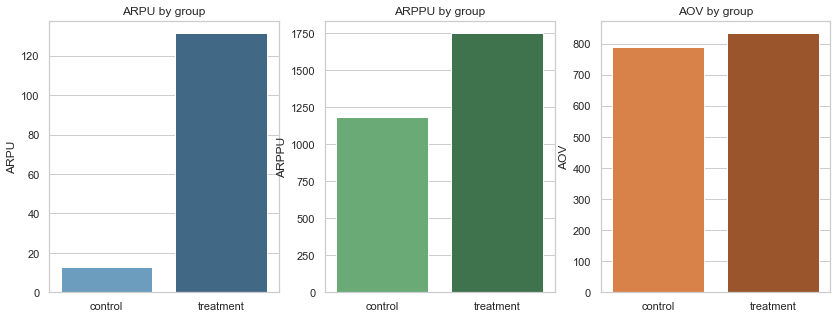

In [260]:
metrics_df = pd.DataFrame({'ARPU': exp_arpu,'ARPPU': exp_arppu,'AOV': exp_aov}).reset_index()
sns.set(style="whitegrid")
plt.figure(figsize=(14,5))

# ARPU
plt.subplot(1,3,1)
sns.barplot(x='group', y='ARPU', data=metrics_df, palette='Blues_d')
plt.title('ARPU by group')
plt.ylabel('ARPU')
plt.xlabel('')

# ARPPU
plt.subplot(1,3,2)
sns.barplot(x='group', y='ARPPU', data=metrics_df, palette='Greens_d')
plt.title('ARPPU by group')
plt.ylabel('ARPPU')
plt.xlabel('')

# AOV
plt.subplot(1,3,3)
sns.barplot(x='group', y='AOV', data=metrics_df, palette='Oranges_d')
plt.title('AOV by group')
plt.ylabel('AOV')
plt.xlabel('')
plt.show()

**Intermediate Conclusion**

Secondary metrics also show a clear advantage for the treatment group across all indicators.

**Guardrail Metric**

**Total revenue**

In [261]:
# Total revenue
exp_total_rev = exp_orders.groupby('group')['revenue'].sum()
print("\nTotal revenue:\n", exp_total_rev.to_string(index=True))


Total revenue:
 group
control      18,918.65
treatment   192,279.85


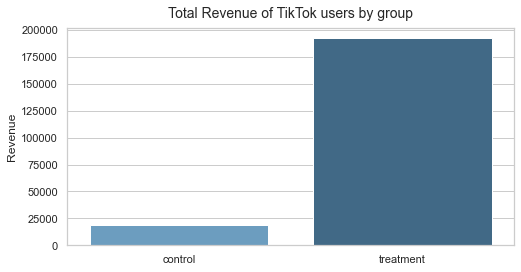

In [266]:
rev_df = exp_total_rev.reset_index()
rev_df.columns = ['group', 'total_revenue']

sns.set(style="whitegrid")
plt.figure(figsize=(8,4))
sns.barplot(x='group', y='total_revenue', data=rev_df, palette='Blues_d')
plt.title('Total Revenue of TikTok users by group', pad=10, fontsize=14)
plt.xlabel('')
plt.ylabel('Revenue')
plt.show()

**Revenue Dynamics Over Time**

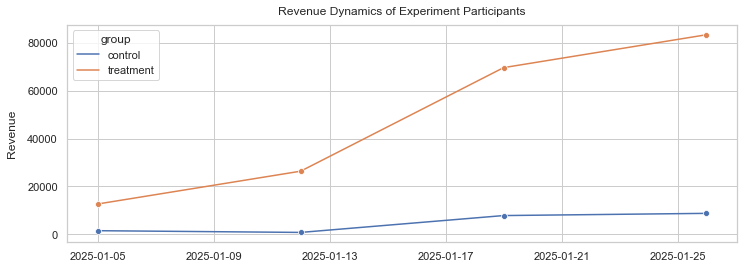

In [267]:
# Revenue dynamics
exp_orders['order_date_dt'] = pd.to_datetime(exp_orders['order_date'], errors='coerce')
exp_orders['order_week'] = exp_orders['order_date_dt'].dt.to_period('W').dt.start_time

# Group by week and group and calculate total revenue
exp_weekly = exp_orders.groupby(['order_week','group'])['revenue'].sum().reset_index()
exp_weekly['order_week_end'] = exp_weekly['order_week'] + pd.Timedelta(days=6)

plt.figure(figsize=(12,4))
sns.lineplot(data=exp_weekly, x='order_week_end', y='revenue', hue='group', marker='o')
plt.title('Revenue Dynamics of Experiment Participants', pad=10)
plt.ylabel('Revenue', labelpad=10)
plt.xlabel('')
plt.show()

**Intermediate Conclusion**

The guardrail metric - total revenue from experiment participants - also shows a significant increase in the treatment group compared to the control group.
This growth is clearly visible in the revenue dynamics chart, confirming that the bonus not only increases conversion but also leads to higher overall revenue.

### Stage 5 Conclusions

**Key Findings**
- Conversion rate in the treatment group increased almost sevenfold: 
control - 1.0%, treatment - 7.5%.
The statistical test confirms that the difference is statistically significant.

- Average revenue per user (ARPU) is significantly higher in the treatment group:
control - 12.5, treatment - 131.

- Paying users generate higher revenue in the treatment group:
control - 1,182, treatment - 1,748.

- Average order value (AOV) increased slightly, but the difference is less pronounced compared to ARPU and ARPPU:
control - 788, treatment - 832.

- Total revenue in the treatment group increased by more than 10×:
control - 18.9k, treatment - 192.2k.

Overall, the experiment demonstrates a clear positive impact of the bonus program across all key metrics: conversion, revenue per user, and total revenue.
Rolling out the bonus program is recommended for further scaling.

**Experiment Limitations**

- Sample size and event sparsity.
Only 255 orders were observed among ~3,000 users, with just 126 unique buyers.
A low number of conversion events may lead to high variance and affect the stability of statistical significance.

- Seasonality.
Potential seasonal effects (New Year holidays, vacation period) may have influenced user behavior and activity levels.

- Metric imbalance.
The magnitude of revenue and ARPU growth (10×) is unusually high.
Additional validation is required to verify bonus calculation logic, order attribution, and the presence of potential outliers.